Imports

In [1]:
# imports
from esdl import esdl
from esdl.esdl_handler import EnergySystemHandler
import pandas as pd
import numpy as np
import numpy_financial as npf
from decimal import Decimal, ROUND_HALF_UP
import matplotlib.pyplot as plt

In [2]:
# This imports all input variables from BH_input_data.py
from BH_input_data import *

# import all data from ESDL
from NSE_get_data_from_ESDL import *

# Make sure to select the scenario (e.g., pessimistic, most likely, optimistic) in the NSE_get_data_from_ESDL file
# Check the scenario that is selected 

print(f'Current scenario = {current_scenario}')

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
Current scenario = ['most_likely']


In [3]:
(np.array([electricity_price_profiles_2040['Pessimistic'].sum(), electricity_price_profiles_2040["Most likely"].sum(), electricity_price_profiles_2040['Optimistic'].sum()]) / 8760).tolist()

[141.7595329405976, 108.24596625631204, 96.79790905986269]

In [4]:
[e_price_profiles_2030[::-1],e_price_profiles_2040[::-1],e_price_profiles_2050[::-1]]

[[47.1405390855254, 51.70075838335427, 61.0941427386612],
 [96.79790905986269, 108.24596625631204, 141.7595329405976],
 [14.042974621395125, 24.155581412312287, 28.553447486028222]]

Set up calendar_year, business_case_year, operations_years, and decommissioning_years lists

In [5]:
def construct_calendar_year_list(lifetime_investment_variable):
    
    year_construction_start = tender_year + 1
    year_start_operation = year_construction_start + duration_construction
    year_decommissioning_start = (year_start_operation + int(Decimal(lifetime_investment_variable).to_integral_value(rounding=ROUND_HALF_UP)))
    # use Decimal.to_integral_value to prevent python to round to nearest even integral
    # this method uses the same rounding method as Excel (i.e., x.5 is rounded up)

    calendar_year_list = list(range(tender_year, year_decommissioning_start + duration_decommissioning))  

    return calendar_year_list

def construct_business_case_year_list(lifetime_investment_variable):

    business_case_year_list = np.array(range(len(construct_calendar_year_list(lifetime_investment_variable))))
    
    return business_case_year_list

def construct_operations_years_list(lifetime_investment_variable):

    year_construction_start = tender_year + 1
    year_start_operation = year_construction_start + duration_construction

    operations_years_list = list(range(year_start_operation, year_start_operation + int(Decimal(lifetime_investment_variable).to_integral_value(rounding=ROUND_HALF_UP))))
    
    return operations_years_list

def construct_decomissioning_years_list(lifetime_investment_variable):

    year_construction_start = tender_year + 1
    year_start_operation = year_construction_start + duration_construction
    year_decommissioning_start = year_start_operation + int(Decimal(lifetime_investment_variable).to_integral_value(rounding=ROUND_HALF_UP))

    decomissioning_years_list = list(range(year_decommissioning_start, year_decommissioning_start + duration_decommissioning))

    return decomissioning_years_list

Start business case analysis

Construction phase

In [6]:
asset_parameters

name,power,efficiency,investment_costs,fixed_opex,variable_opex,wacc
TNVDW,700000000.0,,1750.0,2.25,5.0,8.5
Electrolyzer,500.0,0.6,2000.0,2.0,0.0,8.25
Offtaker,24900000.0,,0.0,0.0,0.0,10.5


Start business case analysis

Construction phase

In [7]:
def construction_phase(capex_h2_station_variable, 
                       capex_h2_pipeline_variable, 
                       df_capex_atr_variable,
                       inflation_variable,
                       lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows in the construction phase'''

    # set up df
    df_construction_phase = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_construction_phase.columns.name = "construction_phase"
    
    # CASH OUTFLOWS

    #### function to calculate H2 receiving station and H2 pipeline CAPEX
    def calculate_capex():
        ''' This function calculates the yearly capex for each of the construction years'''
        capex_h2_station_list = []
        capex_h2_pipeline_list = []
    
        for x in construct_calendar_year_list(lifetime_investment_variable): 
            if x in construction_years_list:
                capex_h2_station_list.append(-capex_h2_station_variable * (1+inflation_variable)**(x-2028) / duration_construction)
                capex_h2_pipeline_list.append(-capex_h2_pipeline_variable * (1+inflation_variable)**(x-2028) / duration_construction)
                # because we don't have yearly data for the h2 station/h2 pipeline capex I added an inflation term with 2028 the reference year (tender year in base case) to start adding inflation. 
                # If we end up finding 2040/2050 estimates, this should be removed!

            else: 
                capex_h2_station_list.append(0)
                capex_h2_pipeline_list.append(0)
        
        df_construction_phase.loc['capex_h2_station'] = capex_h2_station_list
        df_construction_phase.loc['capex_h2_pipeline'] = capex_h2_pipeline_list

        return df_construction_phase
    
    df_construction_phase = calculate_capex()
    
    # calculate total cash outflows from investments then add to df
    total_cash_outflow_investment = df_construction_phase.loc['capex_h2_station'] + df_construction_phase.loc['capex_h2_pipeline']
    df_construction_phase.loc['total_cash_outflow_investment'] = total_cash_outflow_investment
    

    # AVOIDED COSTS

    ##### function to calculate avoided costs of not investing in ATR+CCS plant
    def calculate_avoided_capex():
        ''' This function calculates the yearly avoided capex for each of the construction years'''
        atr_capex_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            # the capex is divided over the construction years
            if x in construction_years_list:
                atr_capex_list.append(df_capex_atr_variable.loc['bh_atr_capex',tender_year]/duration_construction)

            # check if in operation years and if the atr plant is depricated
            # it is assumed that the re-investment takes place in one year, and the construction is also in 1 year
            # investment is made in the year before it has to be operational, so in year (x+1) it should be deprecated
            elif (x+1) in construct_operations_years_list(lifetime_investment_variable) and (x+1 - construct_operations_years_list(lifetime_investment_variable)[0]) % bh_atr_depreciation == 0:
                atr_capex_list.append(df_capex_atr_variable.loc['bh_atr_capex',x] * ((1+inflation_variable)**i))

            else:
                atr_capex_list.append(0)

        return atr_capex_list
    

    # add avoided ATR costs to df
    df_construction_phase.loc['avoided_capex_atr'] = calculate_avoided_capex()
    
    # This function can probably be deleted, since we have now set duration of operation equal to lifetime of investment
    # #### function - resale value
    # 
    # def resale_value():
    #     '''This function calculates the resale value of the ATR plant if the business case length is not equal to the ATR plant lifetime'''

    #     resale_list = []
    #     yearly_depreciation = df_bh_atr_capex.loc['bh_atr_capex',tender_year]/bh_atr_depreciation

    #     if lifetime_investment_variable > bh_atr_depreciation:
        
    #         # bh_apr_depreciation -1 because the investment is taken in the 25th year
    #         reinvestment_year = construct_operations_years_list(lifetime_investment_variable)[0]  + bh_atr_depreciation -1

    #         reinvestment = df_construction_phase.loc['avoided_capex_atr',reinvestment_year]  

    #         yearly_depreciation_reinvestment = reinvestment / bh_atr_depreciation

    #     else: 
    #         reinvestment = 0

    #     for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            
    #         if x == construct_decomissioning_years_list(lifetime_investment_variable)[0] and lifetime_investment_variable < bh_atr_depreciation:
    #             resale_list.append(-(df_bh_atr_capex.loc['bh_atr_capex',tender_year] - (lifetime_investment_variable) * yearly_depreciation))
            
    #         elif x == construct_decomissioning_years_list(lifetime_investment_variable)[0] and reinvestment != 0:
    #             resale_list.append(-(reinvestment - (lifetime_investment_variable - bh_atr_depreciation) * yearly_depreciation_reinvestment))

    #         else:
    #             resale_list.append(0)

    #     return  resale_list


    # # add resale value to avoided ATR costs in the df
    # df_construction_phase.loc['avoided_capex_atr'] = df_construction_phase.loc['avoided_capex_atr'] + resale_value()

    # calculate total avoided costs and add to df
    total_avoided_costs = df_construction_phase.loc['avoided_capex_atr']
    df_construction_phase.loc['total_avoided_costs'] = total_avoided_costs

    # calculate total cashflow from investments then add to df
    total_cashflow_investment = np.array(total_cash_outflow_investment) + np.array(total_avoided_costs)
    df_construction_phase.loc['total_cashflow_investment'] = total_cashflow_investment

    return df_construction_phase

In [8]:
construction_phase(bh_capex_h2_receiving_station,
                   bh_capex_h2_pipeline,
                   df_bh_atr_capex,
                   bh_inflation,
                   bh_lifetime).style.format(precision=2)

construction_phase,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
capex_h2_station,0.00,-2.12,-2.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
capex_h2_pipeline,0.00,-19.76,-20.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
total_cash_outflow_investment,0.00,-21.88,-22.32,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
avoided_capex_atr,0.00,247.45,247.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
total_avoided_costs,0.00,247.45,247.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
total_cashflow_investment,0.00,225.57,225.13,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Operational phase

In [9]:
def operational_phase(network_costs_h2_variable,
                      h2_price_variable,
                      hwi_costs_variable,
                      df_atr_opex_variable,
                      network_costs_ng_variable,
                      carbon_permits_variable,
                      ng_price_variable,
                      ng_tax_variable,
                      e_price_variable,
                      electricity_tax_variable,
                      inflation_variable,
                      lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows in the operational phase'''

    #construct df
    df_operational_phase = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_operational_phase.columns.name = "operational_phase"
    
    # CASH OUTFLOWS
    
    #### function
    def calculate_network_costs_h2():
        '''This function calculates the h2 network costs for all the operational years'''

        network_costs_h2_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                network_costs_h2_list.append((-network_costs_h2_variable * h2_demand_m3 / 1E6) 
                                             * ((1+inflation_variable)**i))

            else:
                network_costs_h2_list.append(0)

        return network_costs_h2_list

    df_operational_phase.loc['network_costs_h2'] = calculate_network_costs_h2()

    #### function
    def calculate_h2_costs():
        '''This function calculates the costs associated with purchasing H2'''

        h2_costs_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                h2_costs_list.append((-h2_price_variable.loc['bh_h2_price',x] * h2_demand_mwh / 1E6) 
                                     * ((1+inflation_variable)**i))

            else:
                h2_costs_list.append(0)

        return h2_costs_list

    df_operational_phase.loc['purchasing_h2'] = calculate_h2_costs()


    #### function
    def calculate_hwi_costs():
        '''This function calculates the costs associated with purchasing HWI's'''

        hwi_costs_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            # bh_hwi_percentage is the expected percentage of HWI's that is necessary, i.e., 0.42 from 2030, 0.6 from 2035

            if x in construct_operations_years_list(lifetime_investment_variable):
                hwi_costs_list.append(-hwi_costs_variable.loc['bh_hwi_costs',x] * ((1+inflation_variable)**i)
                                      *bh_hwi_percentage.loc['hwi_percentage',x])   #if you want to calculate the business case for 100% HWI's, comment this line!    

            else:
                hwi_costs_list.append(0)

        return hwi_costs_list

    df_operational_phase.loc['purchasing_hwi'] = calculate_hwi_costs()



    # calculate total outflow opex and add to df
    total_outflow_opex = np.array(calculate_network_costs_h2()) + np.array(calculate_h2_costs()) + np.array(calculate_hwi_costs())
    df_operational_phase.loc['total_outflow_opex'] = total_outflow_opex

    # AVOIDED COSTS

    #### function
    def calculate_atr_opex():
        '''This function calculates the avoided atr opex for all the operational years'''

        opex_atr_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                opex_atr_list.append(df_atr_opex_variable.loc['bh_atr_opex',x]*((1 + inflation_variable)**i))

            else:
                opex_atr_list.append(0)

        return opex_atr_list 
    
    df_operational_phase.loc['avoided_atr_opex'] = calculate_atr_opex()


    ##### function
    def calculate_network_costs_ng():
        '''This function calculates the natural gas network costs for all the operational years'''

        network_costs_ng_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                network_costs_ng_list.append((network_costs_ng_variable * ng_demand_m3 / 1E6) 
                                             * ((1+inflation_variable)**i))

            else:
                network_costs_ng_list.append(0)

        return network_costs_ng_list

    df_operational_phase.loc['network_costs_ng'] = calculate_network_costs_ng()
   

    ##### function
    def calculate_eu_permits_costs():
        '''This function calculates the EU carbon permit costs for all the operational years'''

        carbon_permist_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                carbon_permist_list.append((co2_emissions_annual * 1000 * carbon_permits_variable.loc['bh_carbon_permits',x] / 1E6) * 
                                           ((1+inflation_variable)**i))

            else:
                carbon_permist_list.append(0)

        return carbon_permist_list

    df_operational_phase.loc['eu_carbon_permits'] = calculate_eu_permits_costs()


    ##### function
    def calculate_ng_costs():
        '''This function calculates the EU carbon permit costs for all the operational years'''

        ng_costs_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                ng_costs_list.append((ng_price_variable.loc['bh_ng_price',x] * ng_demand_mwh / 1E6) * 
                                     ((1+inflation_variable)**i))

            else:
                ng_costs_list.append(0)

        return ng_costs_list

    df_operational_phase.loc['ng_costs'] = calculate_ng_costs()

    ##### function
    def calculate_ng_tax_costs():
        '''This function calculates the NG tax costs for all the operational years'''

        ng_tax_costs_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                ng_tax_costs_list.append((ng_tax_variable * ng_demand_m3 / 1E6) * 
                                         ((1+inflation_variable)**i))

            else:
                ng_tax_costs_list.append(0)

        return ng_tax_costs_list

    df_operational_phase.loc['ng_tax_costs'] = calculate_ng_tax_costs()

    
    #### function
    def calculate_electricity_costs():
        '''This function calculates the electricity costs for all the operational years'''

        e_costs_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                e_costs_list.append((e_price_variable.loc['bh_e_price',x] * e_demand_mwh / 1E6) * 
                                         ((1+inflation_variable)**i))

            else:
                e_costs_list.append(0)

        return e_costs_list

    df_operational_phase.loc['electricity_costs'] = calculate_electricity_costs()


    ##### function
    def calculate_electricity_tax_costs():
        '''This function calculates the electricity tax costs for all the operational years'''

        electricity_tax_costs_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                electricity_tax_costs_list.append((electricity_tax_variable.loc['bh_electricity_tax',x] * 
                                                   e_demand_mwh / 1E6) * 
                                         ((1+inflation_variable)**i))

            else:
                electricity_tax_costs_list.append(0)

        return electricity_tax_costs_list


    #### function
    def calculate_avoided_hwi_costs():
        '''This function calculates the costs associated with not purchasing 42% HWI's which would have been necessary in the case of blue hydrogen offtake'''

        hwi_avoided_costs_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                hwi_avoided_costs_list.append(hwi_costs_variable.loc['bh_hwi_costs',x] *
                                              ((1+inflation_variable)**i) *
                                              bh_hwi_percentage.loc['hwi_percentage',x])               # In the case of an ATR+CSS still HWI's have to be purchased

            else:
                hwi_avoided_costs_list.append(0)

        return hwi_avoided_costs_list

    df_operational_phase.loc['avoided_purchasing_hwi'] = calculate_avoided_hwi_costs()

    df_operational_phase.loc['electricity_tax_costs'] = calculate_electricity_tax_costs()

    # calculate total avoided costs and add to df 
    total_avoided_costs = (np.array(calculate_atr_opex()) + np.array(calculate_network_costs_ng()) +
                           np.array(calculate_eu_permits_costs()) + np.array(calculate_ng_costs()) +
                           np.array(calculate_ng_tax_costs()) + np.array(calculate_electricity_costs()) +
                           np.array(calculate_electricity_tax_costs()) + np.array(calculate_avoided_hwi_costs()))

    df_operational_phase.loc['total_avoided_costs'] = total_avoided_costs

    # calculate net cashflow from operation (=EBITDA) and add to df
    net_cashflow_operation = total_outflow_opex + total_avoided_costs
    df_operational_phase.loc['net_cashflow_operations'] = net_cashflow_operation
    
    return df_operational_phase

In [10]:
operational_phase(bh_network_costs_h2,
                  bh_h2_price,
                  bh_hwi_costs,
                  df_bh_atr_opex,
                  bh_network_costs_ng,
                  bh_carbon_permits,
                  bh_ng_price,
                  bh_ng_tax_cost,
                  bh_e_price,
                  bh_electricity_tax,
                  bh_inflation,
                  bh_lifetime).style.format(precision=2)

operational_phase,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
network_costs_h2,0.00,0.00,0.00,-56.98,-58.12,-59.28,-60.46,-61.67,-62.91,-64.17,-65.45,-66.76,-68.09,-69.46,-70.84,-72.26,-73.71,-75.18,-76.68,-78.22,-79.78,-81.38,-83.01,-84.67,-86.36,-88.09,-89.85,-91.64,0.00
purchasing_h2,0.00,0.00,0.00,-207.44,-212.68,-218.06,-223.56,-229.20,-234.97,-240.88,-246.93,-253.13,-260.77,-265.98,-261.75,-257.25,-252.46,-247.37,-241.98,-236.28,-230.25,-223.89,-205.99,-210.11,-214.31,-218.60,-222.97,-227.43,0.00
purchasing_hwi,0.00,0.00,0.00,-211.70,-215.94,-220.26,-224.66,-327.36,-333.91,-340.59,-347.40,-354.35,-361.44,-368.67,-376.04,-383.56,-391.23,-399.06,-407.04,-415.18,-423.48,-431.95,-440.59,-449.40,-458.39,-467.56,-476.91,-486.45,0.00
total_outflow_opex,0.00,0.00,0.00,-476.12,-486.74,-497.59,-508.69,-618.24,-631.79,-645.64,-659.79,-674.24,-690.30,-704.11,-708.64,-713.07,-717.40,-721.61,-725.71,-729.68,-733.52,-737.22,-729.58,-744.17,-759.06,-774.24,-789.72,-805.52,0.00
avoided_atr_opex,0.00,0.00,0.00,15.76,16.07,16.39,16.72,17.05,17.40,17.74,18.10,18.46,18.83,19.21,19.59,19.98,20.38,20.79,21.21,21.63,22.06,22.50,22.95,23.41,23.88,24.36,24.85,25.34,0.00
network_costs_ng,0.00,0.00,0.00,15.58,15.89,16.21,16.53,16.86,17.20,17.55,17.90,18.25,18.62,18.99,19.37,19.76,20.15,20.56,20.97,21.39,21.82,22.25,22.70,23.15,23.61,24.09,24.57,25.06,0.00
eu_carbon_permits,0.00,0.00,0.00,2.02,2.16,2.31,2.46,2.62,2.78,2.95,3.13,3.31,3.61,3.68,4.83,6.01,7.25,8.53,9.86,11.23,12.66,14.14,16.93,17.27,17.62,17.97,18.33,18.69,0.00
ng_costs,0.00,0.00,0.00,134.16,136.59,139.07,141.59,144.15,146.76,149.42,152.13,154.88,157.39,160.54,163.22,165.95,168.71,171.53,174.38,177.28,180.23,183.23,185.65,189.36,193.15,197.01,200.95,204.97,0.00
ng_tax_costs,0.00,0.00,0.00,21.77,22.20,22.65,23.10,23.56,24.03,24.51,25.00,25.50,26.01,26.53,27.07,27.61,28.16,28.72,29.30,29.88,30.48,31.09,31.71,32.35,32.99,33.65,34.33,35.01,0.00
electricity_costs,0.00,0.00,0.00,8.48,9.60,10.76,11.96,13.20,14.49,15.82,17.21,18.64,21.23,21.65,20.37,19.03,17.62,16.15,14.62,13.02,11.35,9.60,5.77,5.89,6.01,6.13,6.25,6.38,0.00


In [11]:
def decommissioning_phase(df_capex_atr_variable,inflation_variable,lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows in the decommissioning phase'''
    
    #set up df
    df_decommissioning_phase = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_decommissioning_phase.columns.name = "decommissioning_phase"
    
    #### function 
    def decommissioning_avoided_cost():
        ''' This function calculated the decommissioning costs for all the decommissioning years '''

        decommissioning_avoided_cost_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_decomissioning_years_list(lifetime_investment_variable):
                decommissioning_avoided_cost_list.append(df_capex_atr_variable.loc['bh_atr_capex',tender_year] * bh_decomissioning_percentage /
                                                         len(construct_decomissioning_years_list(lifetime_investment_variable)) *
                                                         ((1+inflation_variable)**i))
                
            else:
                decommissioning_avoided_cost_list.append(0)

        return decommissioning_avoided_cost_list  
    
    # add decommissioning costs to df
    df_decommissioning_phase.loc['decommissioning_avoided_cost'] = decommissioning_avoided_cost()

    #add a row for the total decommissioning cashflows. Includes at this moment only one decommissioning cost, but could include more at a later stage.
    df_decommissioning_phase.loc['total_cashflow_decommissioning'] = decommissioning_avoided_cost() 
    
    
    return df_decommissioning_phase

In [12]:
decommissioning_phase(df_bh_atr_capex,bh_inflation,bh_lifetime)

decommissioning_phase,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,...,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
decommissioning_avoided_cost,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.232604
total_cashflow_decommissioning,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.232604


Taxes & profits - part 1

In [13]:
def taxes_and_profits_part1(capex_h2_station_variable,
                            capex_h2_pipeline_variable,
                            df_capex_atr_variable,
                            network_costs_h2_variable,
                            h2_price_variable,
                            hwi_costs_variable,
                            df_atr_opex_variable,
                            network_costs_ng_variable,
                            carbon_permits_variable,
                            ng_price_variable,
                            ng_tax_variable,
                            e_price_variable,
                            electricity_tax_variable,
                            inflation_variable,
                            lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows for taxes & profits
        It consists of two parts, as it is dependent on the debt and loan calculations'''

    # construct a df
    df_taxes_profits = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_taxes_profits.columns.name = "taxes_and_profits"
    
    #### function
    def h2_infra_depreciation():
        '''This function calculates the depreciation of the H2 receiving station and H2 pipeline'''

        h2_station_depreciation_list = []
        h2_pipeline_depreciation_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):

            if x in construct_operations_years_list(lifetime_investment_variable):
                h2_station_depreciation_list.append(-capex_h2_station_variable/bh_h2_station_depreciation)
                h2_pipeline_depreciation_list.append(-capex_h2_pipeline_variable/bh_h2_pipeline_depreciation)
            else: 
                h2_station_depreciation_list.append(0)
                h2_pipeline_depreciation_list.append(0)

        df_taxes_profits.loc['h2_station_depreciation'] = h2_station_depreciation_list
        df_taxes_profits.loc['h2_pipeline_depreciation'] = h2_pipeline_depreciation_list

        return df_taxes_profits 

    df_taxes_profits = h2_infra_depreciation()        

    #### function
    def atr_depreciation():
        ''' This function calculates the depreciation of the atr capex investment during the operational years'''

        depreciation_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):

            if x in construct_operations_years_list(lifetime_investment_variable): 

                depreciation_list.append(df_capex_atr_variable.loc['bh_atr_capex',tender_year]/bh_atr_depreciation)

            else: 
                depreciation_list.append(0)

        return depreciation_list  
    
    # add atr avoided depreciation to df
    df_taxes_profits.loc['avoided_atr_depreciation'] = atr_depreciation()


    
    # # This function can probably be deleted, since we have now set duration of operation equal to lifetime of investment
    # #### function
    # def resale_value():
    #     '''This function calculates the resale value of the ATR plant if the business case length is not equal to the ATR plant lifetime'''

    #     resale_list = []
    #     yearly_depreciation = df_bh_atr_capex.loc['bh_atr_capex',tender_year]/bh_atr_depreciation

    #     if lifetime_investment_variable > bh_atr_depreciation:
        
    #         # bh_apr_depreciation -1 because the investment is taken in the 25th year
    #         reinvestment_year = construct_operations_years_list(lifetime_investment_variable)[0]  + bh_atr_depreciation -1

    #         reinvestment = construction_phase(capex_h2_station_variable,
    #                                           capex_h2_pipeline_variable,
    #                                           df_capex_atr_variable,
    #                                           inflation_variable,
    #                                           lifetime_investment_variable).loc['avoided_capex_atr',reinvestment_year]

    #         yearly_depreciation_reinvestment = reinvestment / bh_atr_depreciation

    #     else: 
    #         reinvestment = 0

    #     for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            
    #         if x == construct_decomissioning_years_list(lifetime_investment_variable)[0] and lifetime_investment_variable < bh_atr_depreciation:
    #             resale_list.append(-(df_bh_atr_capex.loc['bh_atr_capex',tender_year] - (lifetime_investment_variable) * yearly_depreciation))
            
    #         elif x == construct_decomissioning_years_list(lifetime_investment_variable)[0] and reinvestment != 0:
    #             resale_list.append(-(reinvestment - (lifetime_investment_variable - bh_atr_depreciation) * yearly_depreciation_reinvestment))

    #         else:
    #             resale_list.append(0)

    #     return  resale_list

    # # add resale value atr to df
    # df_taxes_profits.loc['resale_atr'] = resale_value()


    #### function 
    def ebit():
        ''' This function calculates the ebit by adding depreciation (which is negative) to ebitda (net cashflow operations)'''

        net_cashflow_operations = (operational_phase(network_costs_h2_variable,
                                                     h2_price_variable,
                                                     hwi_costs_variable,
                                                     df_atr_opex_variable,
                                                     network_costs_ng_variable,
                                                     carbon_permits_variable,
                                                     ng_price_variable,
                                                     ng_tax_variable,
                                                     e_price_variable,
                                                     electricity_tax_variable,
                                                     inflation_variable,
                                                     lifetime_investment_variable).loc['net_cashflow_operations'])
        
        ebit_list = (np.array(net_cashflow_operations) + 
                     np.array(atr_depreciation()) + 
                    #  np.array(resale_value()) + 
                     np.array(df_taxes_profits.loc['h2_station_depreciation']) + 
                     np.array(df_taxes_profits.loc['h2_pipeline_depreciation']))

        return ebit_list

    # add ebit to df
    df_taxes_profits.loc['ebit'] = ebit()

    
    return df_taxes_profits

In [14]:
taxes_and_profits_part1(bh_capex_h2_receiving_station,
                        bh_capex_h2_pipeline,
                        df_bh_atr_capex,
                        bh_network_costs_h2,
                        bh_h2_price,
                        bh_hwi_costs,
                        df_bh_atr_opex,
                        bh_network_costs_ng,
                        bh_carbon_permits,
                        bh_ng_price,
                        bh_ng_tax_cost,
                        bh_e_price,
                        bh_electricity_tax,
                        bh_inflation,
                        bh_lifetime).style.format(precision=2)

taxes_and_profits,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
h2_station_depreciation,0.00,0.00,0.00,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,0.00
h2_pipeline_depreciation,0.00,0.00,0.00,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,0.00
avoided_atr_depreciation,0.00,0.00,0.00,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,0.00
ebit,0.00,0.00,0.00,-48.26,-49.89,-51.55,-53.26,-55.00,-56.79,-58.62,-60.49,-62.40,-64.72,-66.37,-59.69,-52.70,-45.41,-37.79,-29.85,-21.56,-12.92,-3.93,15.25,15.20,15.14,15.08,15.02,14.96,0.00


Debt and loan - part 1

In [15]:
def debt_and_loan_part1(capex_h2_station_variable,
                        capex_h2_pipeline_variable,
                        loan_percentage_variable,
                        loan_interest_rate_variable,
                        lifetime_investment_variable):
    
    ''' This function creates a dataframe that contains all cashflows for debt and loans
        It consists of two parts because it is dependent on the taxes & profits calculations'''

    # construct df
    row_names = [
    "begin_of_year",
    "drawdown",
    "repayment_capital",
    "end_of_year",
    "repayment_interest",]

    df_debt_and_loan = pd.DataFrame(0.0, index=row_names, columns=construct_calendar_year_list(lifetime_investment_variable))
    df_debt_and_loan.columns.name = "debt_and_loan"

    #### function
    def debt_drawdown(capex_h2_station_variable,capex_h2_pipeline_variable,loan_percentage_variable):
        ''' This function calculates the amount that is lent for the capex investments for each of the consturction years'''   

        drawdown_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):
            if x in construction_years_list:
                drawdown_list.append((capex_h2_station_variable + capex_h2_pipeline_variable) * 
                                     loan_percentage_variable / duration_construction)
            else: 
                drawdown_list.append(0)

        return drawdown_list  

    # add debt drawdown to df
    df_debt_and_loan.loc["drawdown"] = debt_drawdown(capex_h2_station_variable,capex_h2_pipeline_variable,loan_percentage_variable)

    #### function
    def debt_calculations(loan_interest_rate_variable):
        ''' This function calculates debt at the begin of the year, debt at the end of the year, 
            repayment of interest and repayment of capital. 
            These are dependent on each other and therefore combined into one function'''


        for x in construct_calendar_year_list(lifetime_investment_variable):
        
            #begin of year
            if x == tender_year:
                df_debt_and_loan.loc['begin_of_year',x] = 0
            else:
                df_debt_and_loan.loc['begin_of_year',x] = df_debt_and_loan.loc['end_of_year',x-1]
        
            #repayment interest
            if x in construct_operations_years_list(lifetime_investment_variable):
                df_debt_and_loan.loc['repayment_interest',x] = (-(df_debt_and_loan.loc['begin_of_year',x] + 
                                                               df_debt_and_loan.loc['drawdown',x]) * loan_interest_rate_variable)

            else:
                df_debt_and_loan.loc['repayment_interest',x] = 0

            #repayment capital
            if x in construct_operations_years_list(lifetime_investment_variable):

                # the min-function returns the lowest item, so min(5,10) will return 5
                df_debt_and_loan.loc['repayment_capital',x] = (-min(df_debt_and_loan.loc['begin_of_year',x] + 
                                                                 df_debt_and_loan.loc['drawdown',x], 
                                                                 bh_annuity_loan + df_debt_and_loan.loc['repayment_interest',x]))

            else: 
                df_debt_and_loan.loc['repayment_capital',x] = 0
        
            #end of year
            df_debt_and_loan.loc['end_of_year',x] = (df_debt_and_loan.loc['begin_of_year',x] + df_debt_and_loan.loc['drawdown',x] + 
                                                  df_debt_and_loan.loc['repayment_capital',x])

        return df_debt_and_loan


    return debt_calculations(loan_interest_rate_variable)
    


In [16]:
debt_and_loan_part1(bh_capex_h2_receiving_station,
                    bh_capex_h2_pipeline,
                    bh_loan_percentage,
                    bh_loan_interest_rate,
                    bh_lifetime).style.format(precision=2)

debt_and_loan,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
begin_of_year,0.00,0.00,16.09,32.17,30.89,29.52,28.06,26.49,24.81,23.02,21.09,19.04,16.84,14.48,11.97,9.27,6.39,3.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
drawdown,0.00,16.09,16.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_capital,0.00,0.00,0.00,-1.28,-1.37,-1.47,-1.57,-1.68,-1.80,-1.92,-2.06,-2.20,-2.35,-2.52,-2.70,-2.88,-3.09,-3.30,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
end_of_year,0.00,16.09,32.17,30.89,29.52,28.06,26.49,24.81,23.02,21.09,19.04,16.84,14.48,11.97,9.27,6.39,3.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_interest,0.00,0.00,0.00,-2.25,-2.16,-2.07,-1.96,-1.85,-1.74,-1.61,-1.48,-1.33,-1.18,-1.01,-0.84,-0.65,-0.45,-0.23,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00


Avoided debt and loan - part 1

In [17]:
def avoided_debt_and_loan_part1(df_capex_atr_variable,
                                loan_percentage_variable,
                                loan_interest_rate_variable,
                                lifetime_investment_variable):
    
    ''' This function creates a dataframe that contains all cashflows for debt and loans
        It consists of two parts because it is dependent on the taxes & profits calculations'''

    # construct df
    row_names = [
    "begin_of_year",
    "drawdown",
    "repayment_capital",
    "end_of_year",
    "repayment_interest",]

    df_debt_and_loan = pd.DataFrame(0.0, index=row_names, columns=construct_calendar_year_list(lifetime_investment_variable))
    df_debt_and_loan.columns.name = "avoided_debt_and_loan"

    #### function
    def debt_drawdown(df_capex_atr_variable,loan_percentage_variable):
        ''' This function calculates the amount that is lent for the capex investments for each of the consturction years'''   

        drawdown_list = []

        # At this moment no additional debt is added from the re-investment. Does this make sense? Or should this still be included?
        for x in construct_calendar_year_list(lifetime_investment_variable):
            if x in construction_years_list:
                drawdown_list.append((df_capex_atr_variable.loc['bh_atr_capex',tender_year]) * 
                                     loan_percentage_variable / duration_construction)
            else: 
                drawdown_list.append(0)

        return drawdown_list  

    # add debt drawdown to df
    df_debt_and_loan.loc["drawdown"] = debt_drawdown(df_capex_atr_variable,loan_percentage_variable)

    #### function
    def debt_calculations(loan_interest_rate_variable):
        ''' This function calculates debt at the begin of the year, debt at the end of the year, 
            repayment of interest and repayment of capital. 
            These are dependent on each other and therefore combined into one function'''


        for x in construct_calendar_year_list(lifetime_investment_variable):
        
            #begin of year
            if x == tender_year:
                df_debt_and_loan.loc['begin_of_year',x] = 0
            else:
                df_debt_and_loan.loc['begin_of_year',x] = df_debt_and_loan.loc['end_of_year',x-1]
        
            #repayment interest
            if x in construct_operations_years_list(lifetime_investment_variable):
                df_debt_and_loan.loc['repayment_interest',x] = (-(df_debt_and_loan.loc['begin_of_year',x] + 
                                                               df_debt_and_loan.loc['drawdown',x]) * loan_interest_rate_variable)

            else:
                df_debt_and_loan.loc['repayment_interest',x] = 0

            #repayment capital
            if x in construct_operations_years_list(lifetime_investment_variable):

                # the min-function returns the lowest item, so min(5,10) will return 5
                df_debt_and_loan.loc['repayment_capital',x] = (-min(df_debt_and_loan.loc['begin_of_year',x] + 
                                                                 df_debt_and_loan.loc['drawdown',x], 
                                                                 bh_atr_annuity_loan + df_debt_and_loan.loc['repayment_interest',x]))

            else: 
                df_debt_and_loan.loc['repayment_capital',x] = 0
        
            #end of year
            df_debt_and_loan.loc['end_of_year',x] = (df_debt_and_loan.loc['begin_of_year',x] + df_debt_and_loan.loc['drawdown',x] + 
                                                  df_debt_and_loan.loc['repayment_capital',x])

        return df_debt_and_loan


    return debt_calculations(loan_interest_rate_variable)
    


In [18]:
avoided_debt_and_loan_part1(df_bh_atr_capex,
                            bh_loan_percentage,
                            bh_loan_interest_rate,
                            bh_lifetime).style.format(precision=2)

avoided_debt_and_loan,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
begin_of_year,0.00,0.00,185.59,371.17,356.40,340.60,323.69,305.59,286.23,265.51,243.35,219.63,194.25,167.09,138.04,106.95,73.68,38.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
drawdown,0.00,185.59,185.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_capital,0.00,0.00,0.00,-14.77,-15.80,-16.91,-18.09,-19.36,-20.72,-22.17,-23.72,-25.38,-27.16,-29.06,-31.09,-33.27,-35.60,-38.09,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
end_of_year,0.00,185.59,371.17,356.40,340.60,323.69,305.59,286.23,265.51,243.35,219.63,194.25,167.09,138.04,106.95,73.68,38.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_interest,0.00,0.00,0.00,-25.98,-24.95,-23.84,-22.66,-21.39,-20.04,-18.59,-17.03,-15.37,-13.60,-11.70,-9.66,-7.49,-5.16,-2.67,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00


Taxes & profits - part 2

In [19]:
def taxes_and_profits_part2(capex_h2_station_variable,
                            capex_h2_pipeline_variable,
                            df_capex_atr_variable,
                            network_costs_h2_variable,
                            h2_price_variable,
                            hwi_price_variable,
                            df_atr_opex_variable,
                            network_costs_ng_variable,
                            carbon_permits_variable,
                            ng_price_variable,
                            ng_tax_variable,
                            e_price_variable,
                            electricity_tax_variable,
                            inflation_variable,
                            loan_percentage_variable,
                            loan_interest_rate_variable,
                            income_tax_rate_variable,
                            lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows for taxes and profits
        This is the second part of the taxes and profits calculations.'''

    # load the dataframe that was constructed in part 1 of the taxes and profits calculations
    df_taxes_profits = taxes_and_profits_part1(capex_h2_station_variable,
                                               capex_h2_pipeline_variable,
                                               df_capex_atr_variable,
                                               network_costs_h2_variable,
                                               h2_price_variable,
                                               hwi_price_variable,
                                               df_atr_opex_variable,
                                               network_costs_ng_variable,
                                               carbon_permits_variable,
                                               ng_price_variable,
                                               ng_tax_variable,
                                               e_price_variable,
                                               electricity_tax_variable,
                                               inflation_variable,
                                               lifetime_investment_variable)

    # the interest costs were calculated in the debt_and_loan_part1 function
    # they are imported into this dataframe because they are used to calculate ebt from ebit
    interest_costs = np.array(debt_and_loan_part1(capex_h2_station_variable,
                                                  capex_h2_pipeline_variable,
                                                  loan_percentage_variable,
                                                  loan_interest_rate_variable,
                                                  lifetime_investment_variable).loc['repayment_interest'])   
    
    df_taxes_profits.loc['interest_costs'] = interest_costs

    # Interest savings - i.e., these are the avoided debt payments for the ATR+CCS installation
    avoided_interest_costs = np.array(-avoided_debt_and_loan_part1(df_capex_atr_variable,
                                                                  loan_percentage_variable,
                                                                  loan_interest_rate_variable,
                                                                  lifetime_investment_variable).loc['repayment_interest'])

    df_taxes_profits.loc['avoided_interest_costs'] = avoided_interest_costs

    # the ebt is calculated by adding the ebit to the interest costs (which is negative) and added to the df
    ebit = df_taxes_profits.loc['ebit'].tolist()
    ebt = ebit + interest_costs + avoided_interest_costs
    df_taxes_profits.loc['ebt'] = ebt

    #### function
    def tax_expenses(income_tax_rate_variable):
        '''This function calculates the taxes that have to be paid if ebt is positive'''

        tax_expenses_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):   
            # Normally we only add tax expenses here if ebt>0. 
            # However, here we always add tax expenses, and sometimes it is >0, which indicates tax savings instead of tax expenses
            # But check this logic, because from the formula I am not sure if this is a correct way to do this
                tax_expenses_list.append(-ebt[i] * income_tax_rate_variable)

        return tax_expenses_list
    
    # add tax expenses to df 
    df_taxes_profits.loc['tax_expenses_or_savings'] = tax_expenses(income_tax_rate_variable)

    # calculate net profits by adding tax expenses to ebt and add to df
    net_profits =  ebt + np.array(tax_expenses(income_tax_rate_variable))
    df_taxes_profits.loc['net_profits'] = net_profits

    return df_taxes_profits

In [20]:
taxes_and_profits_part2(bh_capex_h2_receiving_station,
                        bh_capex_h2_pipeline,
                        df_bh_atr_capex,
                        bh_network_costs_h2,
                        bh_h2_price,
                        bh_hwi_costs,
                        df_bh_atr_opex,
                        bh_network_costs_ng,
                        bh_carbon_permits,
                        bh_ng_price,
                        bh_ng_tax_cost,
                        bh_e_price,
                        bh_electricity_tax,
                        bh_inflation,
                        bh_loan_percentage,
                        bh_loan_interest_rate,
                        bh_income_tax_rate,
                        bh_lifetime).style.format(precision=2)

taxes_and_profits,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
h2_station_depreciation,0.00,0.00,0.00,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,-0.17,0.00
h2_pipeline_depreciation,0.00,0.00,0.00,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,-1.55,0.00
avoided_atr_depreciation,0.00,0.00,0.00,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,19.80,0.00
ebit,0.00,0.00,0.00,-48.26,-49.89,-51.55,-53.26,-55.00,-56.79,-58.62,-60.49,-62.40,-64.72,-66.37,-59.69,-52.70,-45.41,-37.79,-29.85,-21.56,-12.92,-3.93,15.25,15.20,15.14,15.08,15.02,14.96,0.00
interest_costs,0.00,0.00,0.00,-2.25,-2.16,-2.07,-1.96,-1.85,-1.74,-1.61,-1.48,-1.33,-1.18,-1.01,-0.84,-0.65,-0.45,-0.23,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
avoided_interest_costs,-0.00,-0.00,-0.00,25.98,24.95,23.84,22.66,21.39,20.04,18.59,17.03,15.37,13.60,11.70,9.66,7.49,5.16,2.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
ebt,0.00,0.00,0.00,-24.53,-27.10,-29.78,-32.56,-35.46,-38.49,-41.64,-44.93,-48.36,-52.30,-55.69,-50.86,-45.87,-40.70,-35.36,-29.85,-21.56,-12.92,-3.93,15.25,15.20,15.14,15.08,15.02,14.96,0.00
tax_expenses_or_savings,-0.00,-0.00,-0.00,6.33,6.99,7.68,8.40,9.15,9.93,10.74,11.59,12.48,13.49,14.37,13.12,11.83,10.50,9.12,7.70,5.56,3.33,1.01,-3.94,-3.92,-3.91,-3.89,-3.88,-3.86,-0.00
net_profits,0.00,0.00,0.00,-18.20,-20.11,-22.09,-24.16,-26.31,-28.56,-30.90,-33.34,-35.88,-38.80,-41.32,-37.74,-34.03,-30.20,-26.24,-22.15,-16.00,-9.59,-2.91,11.32,11.28,11.23,11.19,11.15,11.10,0.00


Debt & loan - part 2

In [21]:
def debt_and_loan_part2(capex_h2_station_variable,
                        capex_h2_pipeline_variable,
                        df_capex_atr_variable,
                        network_costs_h2_variable,
                        h2_price_variable,
                        hwi_price_variable,
                        df_atr_opex_variable,
                        network_costs_ng_variable,
                        carbon_permits_variable,
                        ng_price_variable,
                        ng_tax_variable,
                        e_price_variable,
                        electricity_tax_variable,
                        inflation_variable,
                        loan_percentage_variable,
                        loan_interest_rate_variable,
                        income_tax_rate_variable,
                        lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows for debt and loans
        This is the second part of the debt and loans calculations.'''

    # inport the df from debt_and_loan_part1 to continue with the same df
    df_debt_and_loan = debt_and_loan_part1(capex_h2_station_variable,
                                           capex_h2_pipeline_variable,
                                           loan_percentage_variable,
                                           loan_interest_rate_variable,
                                           lifetime_investment_variable)

    # the tax expenses were calculated in taxes_and_profits_part2 and are imported here
    # the cashflow available for debt is calculated by adding tax expenses to the net cashflow of operations
    # add cashflow for debt to df
    tax_expenses_or_savings = (taxes_and_profits_part2(capex_h2_station_variable,
                                                       capex_h2_pipeline_variable,
                                                       df_capex_atr_variable,
                                                       network_costs_h2_variable,
                                                       h2_price_variable,
                                                       hwi_price_variable,
                                                       df_atr_opex_variable,
                                                       network_costs_ng_variable,
                                                       carbon_permits_variable,
                                                       ng_price_variable,
                                                       ng_tax_variable,
                                                       e_price_variable,
                                                       electricity_tax_variable,
                                                       inflation_variable,
                                                       loan_percentage_variable,
                                                       loan_interest_rate_variable,
                                                       income_tax_rate_variable,
                                                       lifetime_investment_variable).loc['tax_expenses_or_savings'])
    
    net_cashflow_operations = (operational_phase(network_costs_h2_variable,
                                                 h2_price_variable,
                                                 hwi_price_variable,
                                                 df_atr_opex_variable,
                                                 network_costs_ng_variable,
                                                 carbon_permits_variable,
                                                 ng_price_variable,
                                                 ng_tax_variable,
                                                 e_price_variable,
                                                 electricity_tax_variable,
                                                 inflation_variable,
                                                 lifetime_investment_variable).loc['net_cashflow_operations'])
    
    cash_flow_for_debt = np.array(tax_expenses_or_savings) + np.array(net_cashflow_operations)
    df_debt_and_loan.loc['cash_flow_for_debt'] = cash_flow_for_debt

    #### function
    def debt_service():
        ''' This function calculates debt service (i.e. capital and interest repayments)'''
        debt_service_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable): 
            debt_service_list.append(df_debt_and_loan.loc['repayment_capital',x] + df_debt_and_loan.loc['repayment_interest',x])

        return debt_service_list
    
    # add debt service to df
    df_debt_and_loan.loc['debt_service'] = debt_service()

    # calculate cash after debt service and add it to the df
    cash_after_debt_service = cash_flow_for_debt + debt_service()
    df_debt_and_loan.loc['cash_after_debt_service'] = cash_after_debt_service
    
    return df_debt_and_loan

In [22]:
debt_and_loan_part2(bh_capex_h2_receiving_station,
                    bh_capex_h2_pipeline,
                    df_bh_atr_capex,
                    bh_network_costs_h2,
                    bh_h2_price,
                    bh_hwi_costs,
                    df_bh_atr_opex,
                    bh_network_costs_ng,
                    bh_carbon_permits,
                    bh_ng_price,
                    bh_ng_tax_cost,
                    bh_e_price,
                    bh_electricity_tax,
                    bh_inflation,
                    bh_loan_percentage,
                    bh_loan_interest_rate,
                    bh_income_tax_rate,
                    bh_lifetime).style.format(precision=2)

debt_and_loan,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
begin_of_year,0.00,0.00,16.09,32.17,30.89,29.52,28.06,26.49,24.81,23.02,21.09,19.04,16.84,14.48,11.97,9.27,6.39,3.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
drawdown,0.00,16.09,16.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_capital,0.00,0.00,0.00,-1.28,-1.37,-1.47,-1.57,-1.68,-1.80,-1.92,-2.06,-2.20,-2.35,-2.52,-2.70,-2.88,-3.09,-3.30,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
end_of_year,0.00,16.09,32.17,30.89,29.52,28.06,26.49,24.81,23.02,21.09,19.04,16.84,14.48,11.97,9.27,6.39,3.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_interest,0.00,0.00,0.00,-2.25,-2.16,-2.07,-1.96,-1.85,-1.74,-1.61,-1.48,-1.33,-1.18,-1.01,-0.84,-0.65,-0.45,-0.23,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
cash_flow_for_debt,0.00,0.00,0.00,-60.01,-60.97,-61.95,-62.93,-63.93,-64.94,-65.95,-66.98,-68.01,-69.30,-70.08,-64.65,-58.95,-52.99,-46.75,-40.23,-34.08,-27.67,-20.99,-6.76,-6.80,-6.85,-6.89,-6.93,-6.98,0.00
debt_service,0.00,0.00,0.00,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-3.53,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
cash_after_debt_service,0.00,0.00,0.00,-63.54,-64.51,-65.48,-66.47,-67.46,-68.47,-69.48,-70.51,-71.54,-72.84,-73.62,-68.18,-62.48,-56.52,-50.28,-40.23,-34.08,-27.67,-20.99,-6.76,-6.80,-6.85,-6.89,-6.93,-6.98,0.00


Project reserves

In [23]:
def project_reserves(capex_h2_station_variable,
                     capex_h2_pipeline_variable,
                     inflation_variable, 
                     lifetime_investment_variable):
    '''This function creates a dataframe that contains all cashflows for project reserves (i.e., contingency) '''

    #construct df
    row_names = [
    "contingency_injection",
    "contingency_reserve_balance",
    "contingency_reserve_to_dividents",]

    df_project_reserves = pd.DataFrame(0.0, index=row_names, columns=construct_calendar_year_list(lifetime_investment_variable))
    df_project_reserves.columns.name = "project_reserves"

    #### function 
    def contingency_injection():
        '''This function calculates the contingency required for the project'''
        contingency_injection_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):
            
            if x == tender_year:
                contingency_injection_list.append(-((capex_h2_station_variable * (1+inflation_variable)**(x-2028)) + 
                                                    (capex_h2_pipeline_variable * (1+inflation_variable)**(x-2028))) *
                                                     bh_contingency)
        
            else:
                contingency_injection_list.append(0)

        return contingency_injection_list

    # add contingency injection to df
    df_project_reserves.loc['contingency_injection'] = contingency_injection()


    #### function to calculate contingency reserve balance and contingency reserve to dividents
    def contingency_project():
        ''' This function calculates the balance of contingency for each year 
            and the amount that is left over in the last year that is going to dividents'''

        for x in construct_calendar_year_list(lifetime_investment_variable):

            #contingency_reserve_balance
            if x == tender_year:
                df_project_reserves.loc['contingency_reserve_balance',x] = -df_project_reserves.loc['contingency_injection',x]
            else: 
                df_project_reserves.loc['contingency_reserve_balance',x] = (df_project_reserves.loc['contingency_reserve_balance',x-1] -
                                                                         df_project_reserves.loc['contingency_injection',x] - 
                                                                         df_project_reserves.loc['contingency_reserve_to_dividents',x])

            #contingency_reserve_to_dividents
            if (x == construct_calendar_year_list(lifetime_investment_variable)[-1] and 
                                                  df_project_reserves.loc['contingency_reserve_balance',x] > 0):
                df_project_reserves.loc['contingency_reserve_to_dividents',x] = df_project_reserves.loc['contingency_reserve_balance',x]
            else:
                df_project_reserves.loc['contingency_reserve_to_dividents',x] = 0

        return df_project_reserves


    return contingency_project()

In [24]:
project_reserves(bh_capex_h2_receiving_station, bh_capex_h2_pipeline, bh_inflation, bh_lifetime).style.format(precision=2)

project_reserves,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
contingency_injection,-4.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
contingency_reserve_balance,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29,4.29
contingency_reserve_to_dividents,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.29


Equity funding

In [25]:
def equity_funding(capex_h2_station_variable,
                   capex_h2_pipeline_variable,
                   df_capex_atr_variable,
                   network_costs_h2_variable,
                   h2_price_variable,
                   hwi_price_variable,
                   df_atr_opex_variable,
                   network_costs_ng_variable,
                   carbon_permits_variable,
                   ng_price_variable,
                   ng_tax_variable,
                   e_price_variable,
                   electricity_tax_variable,
                   inflation_variable,
                   loan_percentage_variable,
                   loan_interest_rate_variable,
                   income_tax_rate_variable,
                   lifetime_investment_variable):
    '''This function creates a dataframe that contains all cashflows for equity funding '''

    # construct df
    df_equity_funding = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_equity_funding.columns.name = "equity_funding"
    
    # get input data required for calculations
    contingency_injection = project_reserves(capex_h2_station_variable,
                                             capex_h2_pipeline_variable,
                                             inflation_variable,
                                             lifetime_investment_variable).loc['contingency_injection']

    total_cashflow_decommissioning = decommissioning_phase(df_capex_atr_variable,
                                                           inflation_variable,
                                                           lifetime_investment_variable).loc['total_cashflow_decommissioning']

    cash_after_debt_service = (debt_and_loan_part2(capex_h2_station_variable,
                                                   capex_h2_pipeline_variable,
                                                   df_capex_atr_variable,
                                                   network_costs_h2_variable,
                                                   h2_price_variable,
                                                   hwi_price_variable,
                                                   df_atr_opex_variable,
                                                   network_costs_ng_variable,
                                                   carbon_permits_variable,
                                                   ng_price_variable,
                                                   ng_tax_variable,
                                                   e_price_variable,
                                                   electricity_tax_variable,
                                                   inflation_variable,
                                                   loan_percentage_variable,
                                                   loan_interest_rate_variable,
                                                   income_tax_rate_variable,
                                                   lifetime_investment_variable).loc['cash_after_debt_service'])
    
    total_cashflow_investment = construction_phase(capex_h2_station_variable,
                                                   capex_h2_pipeline_variable,
                                                   df_capex_atr_variable,
                                                   inflation_variable,
                                                   lifetime_investment_variable).loc['total_cashflow_investment']
    
      
    contingency_reserve_to_dividents = np.array(project_reserves(capex_h2_station_variable,
                                                                 capex_h2_pipeline_variable,
                                                                 inflation_variable,
                                                                 lifetime_investment_variable).loc['contingency_reserve_to_dividents'])

    # calculate equity injection and add to df
    equity_injection = contingency_injection + (total_cashflow_investment *(1-loan_percentage_variable)) + total_cashflow_decommissioning
    df_equity_funding.loc['equity_injection'] = equity_injection

    # calculate dividents results and add to df
    dividents_results = cash_after_debt_service + contingency_reserve_to_dividents
    df_equity_funding.loc['dividents_results'] = dividents_results

    # calculate equity cash flow result and add to df
    equity_cash_flow_result = equity_injection + dividents_results 
    df_equity_funding.loc['equity_cash_flow_result'] = equity_cash_flow_result

    return df_equity_funding

In [26]:
equity_funding(bh_capex_h2_receiving_station,
               bh_capex_h2_pipeline,
               df_bh_atr_capex,
               bh_network_costs_h2,
               bh_h2_price,
               bh_hwi_costs,
               df_bh_atr_opex,
               bh_network_costs_ng,
               bh_carbon_permits,
               bh_ng_price,
               bh_ng_tax_cost,
               bh_e_price,
               bh_electricity_tax,
               bh_inflation,
               bh_loan_percentage,
               bh_loan_interest_rate,
               bh_income_tax_rate,
               bh_lifetime).style.format(precision=2)

equity_funding,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
equity_injection,-4.29,56.39,56.28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.23
dividents_results,0.00,0.00,0.00,-63.54,-64.51,-65.48,-66.47,-67.46,-68.47,-69.48,-70.51,-71.54,-72.84,-73.62,-68.18,-62.48,-56.52,-50.28,-40.23,-34.08,-27.67,-20.99,-6.76,-6.80,-6.85,-6.89,-6.93,-6.98,4.29
equity_cash_flow_result,-4.29,56.39,56.28,-63.54,-64.51,-65.48,-66.47,-67.46,-68.47,-69.48,-70.51,-71.54,-72.84,-73.62,-68.18,-62.48,-56.52,-50.28,-40.23,-34.08,-27.67,-20.99,-6.76,-6.80,-6.85,-6.89,-6.93,-6.98,21.52


Display all cashflows

In [27]:
# # # Display all individual dataframes

# display(construction_phase(bh_capex_h2_receiving_station,bh_capex_h2_pipeline,df_bh_atr_capex,bh_inflation,bh_lifetime).style.format(precision=2))
# display(operational_phase(bh_network_costs_h2,bh_h2_price,bh_hwi_costs,df_bh_atr_opex,bh_network_costs_ng,bh_carbon_permits,bh_ng_price,bh_ng_tax_cost,bh_e_price,bh_electricity_tax,bh_inflation,bh_lifetime).style.format(precision=2))
# display(decommissioning_phase(df_bh_atr_capex,bh_inflation,bh_lifetime).style.format(precision=2))
# display(taxes_and_profits_part2(bh_capex_h2_receiving_station,bh_capex_h2_pipeline,df_bh_atr_capex,bh_network_costs_h2,bh_h2_price,bh_hwi_costs,df_bh_atr_opex,bh_network_costs_ng,bh_carbon_permits,bh_ng_price,bh_ng_tax_cost,bh_e_price,bh_electricity_tax,bh_inflation,bh_loan_percentage,bh_loan_interest_rate,bh_income_tax_rate,bh_lifetime).style.format(precision=2))
# display(debt_and_loan_part2(bh_capex_h2_receiving_station,bh_capex_h2_pipeline,df_bh_atr_capex,bh_network_costs_h2,bh_h2_price,bh_hwi_costs,df_bh_atr_opex,bh_network_costs_ng,bh_carbon_permits,bh_ng_price,bh_ng_tax_cost,bh_e_price,bh_electricity_tax,bh_inflation,bh_loan_percentage,bh_loan_interest_rate,bh_income_tax_rate,bh_lifetime).style.format(precision=2))
# display(project_reserves(bh_capex_h2_receiving_station, bh_capex_h2_pipeline, bh_lifetime).style.format(precision=2))
# display(equity_funding(bh_capex_h2_receiving_station,bh_capex_h2_pipeline,df_bh_atr_capex,bh_network_costs_h2,bh_h2_price,bh_hwi_costs,df_bh_atr_opex,bh_network_costs_ng,bh_carbon_permits,bh_ng_price,bh_ng_tax_cost,bh_e_price,bh_electricity_tax,bh_inflation,bh_loan_percentage,bh_loan_interest_rate,bh_income_tax_rate,bh_lifetime).style.format(precision=2))


In [28]:
# construct large df including all rows
all_dfs = [construction_phase(bh_capex_h2_receiving_station,bh_capex_h2_pipeline,df_bh_atr_capex,bh_inflation,bh_lifetime), 
           operational_phase(bh_network_costs_h2,bh_h2_price,bh_hwi_costs,df_bh_atr_opex,bh_network_costs_ng,bh_carbon_permits,bh_ng_price,bh_ng_tax_cost,bh_e_price,bh_electricity_tax,bh_inflation,bh_lifetime), 
           decommissioning_phase(df_bh_atr_capex,bh_inflation,bh_lifetime), 
           taxes_and_profits_part2(bh_capex_h2_receiving_station,bh_capex_h2_pipeline,df_bh_atr_capex,bh_network_costs_h2,bh_h2_price,bh_hwi_costs,df_bh_atr_opex,bh_network_costs_ng,bh_carbon_permits,bh_ng_price,bh_ng_tax_cost,bh_e_price,bh_electricity_tax,bh_inflation,bh_loan_percentage,bh_loan_interest_rate,bh_income_tax_rate,bh_lifetime), 
           debt_and_loan_part2(bh_capex_h2_receiving_station,bh_capex_h2_pipeline,df_bh_atr_capex,bh_network_costs_h2,bh_h2_price,bh_hwi_costs,df_bh_atr_opex,bh_network_costs_ng,bh_carbon_permits,bh_ng_price,bh_ng_tax_cost,bh_e_price,bh_electricity_tax,bh_inflation,bh_loan_percentage,bh_loan_interest_rate,bh_income_tax_rate,bh_lifetime), 
           project_reserves(bh_capex_h2_receiving_station, bh_capex_h2_pipeline, bh_inflation, bh_lifetime), 
           equity_funding(bh_capex_h2_receiving_station,bh_capex_h2_pipeline,df_bh_atr_capex,bh_network_costs_h2,bh_h2_price,bh_hwi_costs,df_bh_atr_opex,bh_network_costs_ng,bh_carbon_permits,bh_ng_price,bh_ng_tax_cost,bh_e_price,bh_electricity_tax,bh_inflation,bh_loan_percentage,bh_loan_interest_rate,bh_income_tax_rate,bh_lifetime)]

full_df = pd.concat(all_dfs)
# full_df.style.format(precision=2)   #shows the full df

Present value of cash flows

In [29]:
def present_value_cashflows(capex_h2_station_variable,
                            capex_h2_pipeline_variable,
                            df_capex_atr_variable,
                            network_costs_h2_variable,
                            h2_price_variable,
                            hwi_price_variable,
                            df_atr_opex_variable,
                            network_costs_ng_variable,
                            carbon_permits_variable,
                            ng_price_variable,
                            ng_tax_variable,
                            e_price_variable,
                            electricity_tax_variable,
                            inflation_variable,
                            loan_percentage_variable,
                            loan_interest_rate_variable,
                            income_tax_rate_variable,
                            wacc_variable,
                            lifetime_investment_variable):
    ''' This function creates a dataframe that contains all present value cashflows '''

    # construct df
    df_present_value = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_present_value.columns.name = "present_value"
    
    # calculate sum of the net project cashflows and add to df
    total_cashflow_investment = construction_phase(capex_h2_station_variable, 
                                                   capex_h2_pipeline_variable, 
                                                   df_capex_atr_variable,
                                                   inflation_variable,
                                                   lifetime_investment_variable).loc['total_cashflow_investment']

    net_cashflow_operations = (operational_phase(network_costs_h2_variable,
                                                 h2_price_variable,
                                                 hwi_price_variable,
                                                 df_atr_opex_variable,
                                                 network_costs_ng_variable,
                                                 carbon_permits_variable,
                                                 ng_price_variable,
                                                 ng_tax_variable,
                                                 e_price_variable,
                                                 electricity_tax_variable,
                                                 inflation_variable,
                                                 lifetime_investment_variable).loc['net_cashflow_operations'])

    total_cashflow_decommissioning = decommissioning_phase(df_capex_atr_variable,
                                                           inflation_variable, 
                                                           lifetime_investment_variable).loc['total_cashflow_decommissioning']
    
    sum_net_project_cash_flows = total_cashflow_investment + net_cashflow_operations + total_cashflow_decommissioning
    df_present_value.loc['sum_net_project_cash_flows'] = sum_net_project_cash_flows
    
    #### function
    def present_value_net_cashflows():
        '''This function calculates the present value of the net cashflows'''

        present_value_net_cashflows_list = []

        for x in construct_business_case_year_list(lifetime_investment_variable):    
        
            present_value_net_cashflows_list.append(sum_net_project_cash_flows.tolist()[x] / (1 + wacc_variable) ** x)

        return present_value_net_cashflows_list
    
    # add present value of net cashflows to df
    df_present_value.loc['present_value_net_cashflows'] = present_value_net_cashflows()

    #### function
    def cumulative_value_net_cashflows():
        '''This function calculates the cumulative value of the net cashflows'''
        cumulative_value_net_cashflows_list = []

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x == tender_year:
                cumulative_value_net_cashflows_list.append(present_value_net_cashflows()[i])
            else:
                cumulative_value_net_cashflows_list.append(present_value_net_cashflows()[i] + cumulative_value_net_cashflows_list[i-1])

        return cumulative_value_net_cashflows_list

    # add cumulative value of net cashflows to df
    df_present_value.loc['cumulative_value_net_cashflows'] = cumulative_value_net_cashflows()

    #### function 
    def present_value_equity_cashflows():
        '''This function calculates the present value of equity cashflows'''

        present_value_equity_cashflows_list = []
        equity_cash_flow_result = (equity_funding(capex_h2_station_variable,
                                                  capex_h2_pipeline_variable,
                                                  df_capex_atr_variable,
                                                  network_costs_h2_variable,
                                                  h2_price_variable,
                                                  hwi_price_variable,
                                                  df_atr_opex_variable,
                                                  network_costs_ng_variable,
                                                  carbon_permits_variable,
                                                  ng_price_variable,
                                                  ng_tax_variable,
                                                  e_price_variable,
                                                  electricity_tax_variable,
                                                  inflation_variable,
                                                  loan_percentage_variable,
                                                  loan_interest_rate_variable,
                                                  income_tax_rate_variable,
                                                  lifetime_investment_variable).loc['equity_cash_flow_result'].tolist())

        for x in construct_business_case_year_list(lifetime_investment_variable):       
            present_value_equity_cashflows_list.append(equity_cash_flow_result[x] / (1 + wacc_variable) ** x)

        return present_value_equity_cashflows_list

    # add present value of equity cashflows to df
    df_present_value.loc['present_value_equity_cashflows'] = present_value_equity_cashflows()

    return df_present_value

In [30]:
present_value_cashflows(bh_capex_h2_receiving_station,
                        bh_capex_h2_pipeline,
                        df_bh_atr_capex,
                        bh_network_costs_h2,
                        bh_h2_price,
                        bh_hwi_costs,
                        df_bh_atr_opex,
                        bh_network_costs_ng,
                        bh_carbon_permits,
                        bh_ng_price,
                        bh_ng_tax_cost,
                        bh_e_price,
                        bh_electricity_tax,
                        bh_inflation,
                        bh_loan_percentage,
                        bh_loan_interest_rate,
                        bh_income_tax_rate,
                        bh_general_WACC,
                        bh_lifetime).style.format(precision=2)

present_value,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
sum_net_project_cash_flows,0.00,225.57,225.13,-66.34,-67.97,-69.63,-71.34,-73.08,-74.87,-76.70,-78.57,-80.48,-82.80,-84.45,-77.77,-70.78,-63.49,-55.87,-47.93,-39.64,-31.00,-22.01,-2.83,-2.88,-2.94,-3.00,-3.06,-3.12,17.23
present_value_net_cashflows,0.00,204.14,184.38,-49.17,-45.59,-42.27,-39.19,-36.33,-33.68,-31.23,-28.95,-26.84,-24.98,-23.06,-19.22,-15.83,-12.85,-10.23,-7.94,-5.95,-4.21,-2.70,-0.31,-0.29,-0.27,-0.25,-0.23,-0.21,1.05
cumulative_value_net_cashflows,0.00,204.14,388.52,339.35,293.76,251.50,212.31,175.98,142.30,111.07,82.12,55.29,30.30,7.24,-11.98,-27.81,-40.66,-50.89,-58.83,-64.78,-68.99,-71.69,-72.01,-72.30,-72.57,-72.81,-73.04,-73.25,-72.20
present_value_equity_cashflows,-4.29,51.03,46.10,-47.10,-43.27,-39.75,-36.51,-33.54,-30.80,-28.29,-25.98,-23.85,-21.98,-20.10,-16.85,-13.97,-11.44,-9.21,-6.67,-5.11,-3.76,-2.58,-0.75,-0.68,-0.62,-0.57,-0.52,-0.47,1.31


Cumulative equity and debt cashflows

In [31]:
def cumulative_equity_and_debt_cashflows(capex_h2_station_variable,
                                         capex_h2_pipeline_variable,
                                         df_capex_atr_variable,
                                         network_costs_h2_variable,
                                         h2_price_variable,
                                         hwi_price_variable,
                                         df_atr_opex_variable,
                                         network_costs_ng_variable,
                                         carbon_permits_variable,
                                         ng_price_variable,
                                         ng_tax_variable,
                                         e_price_variable,
                                         electricity_tax_variable,
                                         inflation_variable,
                                         loan_percentage_variable,
                                         loan_interest_rate_variable,
                                         income_tax_rate_variable,
                                         lifetime_investment_variable):
    '''This function creates a dataframe that contains the cumulative equity and debt cashflows'''

    # construct df
    df_cumulative_equity_and_debt = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_cumulative_equity_and_debt.columns.name = "cumulative equity and debt"
    
    ### function 
    def cumulative_equity_cashflow():
        ''' This function calculates the cumulative equity cashflow'''

        cumulative_equity_cashflow_list = []
        equity_cash_flow_result = (equity_funding(capex_h2_station_variable,
                                                  capex_h2_pipeline_variable,
                                                  df_capex_atr_variable,
                                                  network_costs_h2_variable,
                                                  h2_price_variable,
                                                  hwi_price_variable,
                                                  df_atr_opex_variable,
                                                  network_costs_ng_variable,
                                                  carbon_permits_variable,
                                                  ng_price_variable,
                                                  ng_tax_variable,
                                                  e_price_variable,
                                                  electricity_tax_variable,
                                                  inflation_variable,
                                                  loan_percentage_variable,
                                                  loan_interest_rate_variable,
                                                  income_tax_rate_variable,
                                                  lifetime_investment_variable).loc['equity_cash_flow_result'].tolist())

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)): 
            if x == tender_year:
                cumulative_equity_cashflow_list.append(equity_cash_flow_result[i])

            else:
                cumulative_equity_cashflow_list.append(equity_cash_flow_result[i] + cumulative_equity_cashflow_list[i-1])

        return cumulative_equity_cashflow_list

    # add cumulative equity cashflow to df
    df_cumulative_equity_and_debt.loc['cumulative_equity_cashflow'] = cumulative_equity_cashflow()

    #### function to calculate cumulative debt cashflow
    def cumulative_debt_cashflow():
        '''This function calculates the cumulative debt cashflow'''

        cumulative_debt_cashflow_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):
            cumulative_debt_cashflow_list.append(-debt_and_loan_part1(capex_h2_station_variable,
                                                                      capex_h2_pipeline_variable,
                                                                      loan_percentage_variable,
                                                                      loan_interest_rate_variable,
                                                                      lifetime_investment_variable).loc['end_of_year',x])

        return cumulative_debt_cashflow_list
    
    # add cumulative debt cashflow to df
    df_cumulative_equity_and_debt.loc['cumulative_debt_cashflow'] = cumulative_debt_cashflow()
    
    return df_cumulative_equity_and_debt

In [32]:
cumulative_equity_and_debt_cashflows(bh_capex_h2_receiving_station,
                                     bh_capex_h2_pipeline,
                                     df_bh_atr_capex,
                                     bh_network_costs_h2,
                                     bh_h2_price,
                                     bh_hwi_costs,
                                     df_bh_atr_opex,
                                     bh_network_costs_ng,
                                     bh_carbon_permits,
                                     bh_ng_price,
                                     bh_ng_tax_cost,
                                     bh_e_price,
                                     bh_electricity_tax,
                                     bh_inflation,
                                     bh_loan_percentage,
                                     bh_loan_interest_rate,
                                     bh_income_tax_rate,
                                     bh_lifetime).style.format(precision=2)   

cumulative equity and debt,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
cumulative_equity_cashflow,-4.29,52.10,108.39,44.84,-19.66,-85.14,-151.61,-219.08,-287.55,-357.03,-427.54,-499.08,-571.91,-645.53,-713.71,-776.19,-832.71,-882.99,-923.22,-957.30,-984.97,-1005.96,-1012.72,-1019.53,-1026.37,-1033.26,-1040.20,-1047.18,-1025.65
cumulative_debt_cashflow,-0.00,-16.09,-32.17,-30.89,-29.52,-28.06,-26.49,-24.81,-23.02,-21.09,-19.04,-16.84,-14.48,-11.97,-9.27,-6.39,-3.30,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00


Discounted cash flows for levelized cost

In [33]:
def discounted_cashflows_for_levelized_cost(capex_h2_station_variable,
                                            capex_h2_pipeline_variable,
                                            df_capex_atr_variable,
                                            network_costs_h2_variable,
                                            h2_price_variable,
                                            hwi_costs_variable,
                                            df_atr_opex_variable,
                                            network_costs_ng_variable,
                                            carbon_permits_variable,
                                            ng_price_variable,
                                            ng_tax_variable,
                                            e_price_variable,
                                            electricity_tax_variable,
                                            inflation_variable,
                                            loan_percentage_variable,
                                            loan_interest_rate_variable,
                                            income_tax_rate_variable,
                                            wacc_variable,
                                            lifetime_investment_variable):
    '''This function creates a dataframe that contains the discounted cashflows for levelized cost calculations'''

    # construct df
    df_discounted_cashflows_for_levelized_cost = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_discounted_cashflows_for_levelized_cost.columns.name = "discounted cashflows for levelized cost"
    
    # prepare discount term
    time = construct_business_case_year_list(lifetime_investment_variable)
    discount_term = (1 + wacc_variable) ** time

    # get dfs required to obtain cash flows

    df_construction_phase = construction_phase(capex_h2_station_variable, 
                                               capex_h2_pipeline_variable, 
                                               df_capex_atr_variable,
                                               inflation_variable,
                                               lifetime_investment_variable)

    df_operational_phase = operational_phase(network_costs_h2_variable,
                                             h2_price_variable,
                                             hwi_costs_variable,
                                             df_atr_opex_variable,
                                             network_costs_ng_variable,
                                             carbon_permits_variable,
                                             ng_price_variable,
                                             ng_tax_variable,
                                             e_price_variable,
                                             electricity_tax_variable,
                                             inflation_variable,
                                             lifetime_investment_variable)

    df_taxes_and_profits = taxes_and_profits_part2(capex_h2_station_variable,
                                                   capex_h2_pipeline_variable,
                                                   df_capex_atr_variable,
                                                   network_costs_h2_variable,
                                                   h2_price_variable,
                                                   hwi_costs_variable,
                                                   df_atr_opex_variable,
                                                   network_costs_ng_variable,
                                                   carbon_permits_variable,
                                                   ng_price_variable,
                                                   ng_tax_variable,
                                                   e_price_variable,
                                                   electricity_tax_variable,
                                                   inflation_variable,
                                                   loan_percentage_variable,
                                                   loan_interest_rate_variable,
                                                   income_tax_rate_variable,
                                                   lifetime_investment_variable)

    df_project_reserves = project_reserves(capex_h2_station_variable,
                                           capex_h2_pipeline_variable, 
                                           inflation_variable,
                                           lifetime_investment_variable)


    # COSTS

    # get capex cash flows
    capex_h2_station = df_construction_phase.loc['capex_h2_station']
    capex_h2_pipeline = df_construction_phase.loc['capex_h2_pipeline']
    
    # calculate dicounted capex cashflows and add to df
    df_discounted_cashflows_for_levelized_cost.loc['capex_h2_station'] = capex_h2_station / discount_term
    df_discounted_cashflows_for_levelized_cost.loc['capex_h2_pipeline'] = capex_h2_pipeline / discount_term

    # calculate discounted operational expenses and add to df
    network_costs = df_operational_phase.loc['network_costs_h2']
    df_discounted_cashflows_for_levelized_cost.loc['network_costs_h2'] = network_costs / discount_term

    purchasing_h2 = df_operational_phase.loc['purchasing_h2']
    df_discounted_cashflows_for_levelized_cost.loc['purchasing_h2'] = purchasing_h2 / discount_term

    purchasing_hwi = df_operational_phase.loc['purchasing_hwi']
    df_discounted_cashflows_for_levelized_cost.loc['purchasing_hwi'] = purchasing_hwi / discount_term

    network_costs = df_operational_phase.loc['network_costs_h2']
    df_discounted_cashflows_for_levelized_cost.loc['network_costs_h2'] = network_costs / discount_term

    # calculate discounted interest costs
    interest_costs = df_taxes_and_profits.loc['interest_costs']
    df_discounted_cashflows_for_levelized_cost.loc['interest_costs'] = interest_costs / discount_term

    # calculate discounted contingency injection
    contingency_injection = df_project_reserves.loc['contingency_injection']
    contingency_to_dividents = df_project_reserves.loc['contingency_reserve_to_dividents']
    df_discounted_cashflows_for_levelized_cost.loc['contingency'] = ((contingency_injection + contingency_to_dividents) / 
                                                                     discount_term)

    # AVOIDED COSTS

    # calculate discounted tax expenses or savings
    tax_expenses = df_taxes_and_profits.loc['tax_expenses_or_savings']
    df_discounted_cashflows_for_levelized_cost.loc['tax_expenses'] = tax_expenses / discount_term
    
    # calculate discounted avoided capex and add to df

    avoided_capex_atr = df_construction_phase.loc['avoided_capex_atr']
    df_discounted_cashflows_for_levelized_cost.loc['avoided_capex_atr'] = avoided_capex_atr / discount_term

    # calculate discounted avoided atr operational expenses
    avoided_atr_opex = df_operational_phase.loc['avoided_atr_opex']
    df_discounted_cashflows_for_levelized_cost.loc['avoided_atr_opex'] = avoided_atr_opex / discount_term

    network_costs_ng = df_operational_phase.loc['network_costs_ng']
    df_discounted_cashflows_for_levelized_cost.loc['network_costs_ng'] = network_costs_ng / discount_term
    
    eu_carbon_permits = df_operational_phase.loc['eu_carbon_permits']
    df_discounted_cashflows_for_levelized_cost.loc['eu_carbon_permits'] = eu_carbon_permits / discount_term

    ng_costs = df_operational_phase.loc['ng_costs']
    df_discounted_cashflows_for_levelized_cost.loc['ng_costs'] = ng_costs / discount_term

    ng_tax_costs = df_operational_phase.loc['ng_tax_costs']
    df_discounted_cashflows_for_levelized_cost.loc['ng_tax_costs'] = ng_tax_costs / discount_term

    e_costs = df_operational_phase.loc['electricity_costs']
    df_discounted_cashflows_for_levelized_cost.loc['electricity_costs'] = e_costs / discount_term

    e_tax_costs = df_operational_phase.loc['electricity_tax_costs']
    df_discounted_cashflows_for_levelized_cost.loc['electricity_tax_costs'] = e_tax_costs / discount_term

    avoided_hwi_costs = df_operational_phase.loc['avoided_purchasing_hwi']
    df_discounted_cashflows_for_levelized_cost.loc['avoided_purchasing_hwi'] = avoided_hwi_costs / discount_term

    # calculate discounted decomissioning cost
    decommissioning_avoided_cost = decommissioning_phase(df_capex_atr_variable,
                                                         inflation_variable,
                                                         lifetime_investment_variable).loc['decommissioning_avoided_cost']
    
    df_discounted_cashflows_for_levelized_cost.loc['decommissioning_avoided_cost'] = (decommissioning_avoided_cost / 
                                                                                      discount_term)

    # calculate discounted avoided interest costs
    avoided_interest_costs = df_taxes_and_profits.loc['avoided_interest_costs']
    df_discounted_cashflows_for_levelized_cost.loc['avoided_interest_costs'] = avoided_interest_costs / discount_term


    #### function   
    def total_electricity_produced(): 
        '''This function discounts the total electricity produced during the operational years'''

        total_electricity_produced_list = []

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construct_operations_years_list(lifetime_investment_variable):
                total_electricity_produced_list.append((h2_demand_mwh) / (1 + wacc_variable) ** i)

            else: 
                total_electricity_produced_list.append(0)
        
        return total_electricity_produced_list

    # add total electricity produced to df
    df_discounted_cashflows_for_levelized_cost.loc['total_h2_consumed'] = total_electricity_produced()
    
    return df_discounted_cashflows_for_levelized_cost



In [34]:
discounted_cashflows_for_levelized_cost(bh_capex_h2_receiving_station,
                                        bh_capex_h2_pipeline,
                                        df_bh_atr_capex,
                                        bh_network_costs_h2,
                                        bh_h2_price,
                                        bh_hwi_costs,
                                        df_bh_atr_opex,
                                        bh_network_costs_ng,
                                        bh_carbon_permits,
                                        bh_ng_price,
                                        bh_ng_tax_cost,
                                        bh_e_price,
                                        bh_electricity_tax,
                                        bh_inflation,
                                        bh_loan_percentage,
                                        bh_loan_interest_rate,
                                        bh_income_tax_rate,
                                        bh_general_WACC,
                                        bh_lifetime).style.format(precision=2)

discounted cashflows for levelized cost,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
capex_h2_station,0.00,-1.92,-1.77,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
capex_h2_pipeline,0.00,-17.88,-16.51,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
network_costs_h2,0.00,0.00,0.00,-42.23,-38.98,-35.98,-33.21,-30.66,-28.30,-26.12,-24.11,-22.26,-20.55,-18.97,-17.51,-16.16,-14.92,-13.77,-12.71,-11.73,-10.83,-10.00,-9.23,-8.52,-7.86,-7.26,-6.70,-6.18,0.00
purchasing_h2,0.00,0.00,0.00,-153.74,-142.65,-132.36,-122.81,-113.94,-105.71,-98.07,-90.98,-84.40,-78.69,-72.64,-64.69,-57.53,-51.10,-45.31,-40.11,-35.44,-31.26,-27.51,-22.90,-21.14,-19.51,-18.01,-16.63,-15.35,0.00
purchasing_hwi,0.00,0.00,0.00,-156.91,-144.84,-133.70,-123.41,-162.74,-150.22,-138.67,-128.00,-118.15,-109.06,-100.68,-92.93,-85.78,-79.18,-73.09,-67.47,-62.28,-57.49,-53.07,-48.99,-45.22,-41.74,-38.53,-35.56,-32.83,0.00
interest_costs,0.00,0.00,0.00,-1.67,-1.45,-1.25,-1.08,-0.92,-0.78,-0.66,-0.54,-0.44,-0.36,-0.28,-0.21,-0.15,-0.09,-0.04,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
contingency,-4.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.26
tax_expenses,-0.00,-0.00,-0.00,4.69,4.69,4.66,4.61,4.55,4.47,4.37,4.27,4.16,4.07,3.92,3.24,2.65,2.13,1.67,1.28,0.83,0.45,0.12,-0.44,-0.39,-0.36,-0.32,-0.29,-0.26,-0.00
avoided_capex_atr,0.00,223.94,202.66,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
avoided_atr_opex,0.00,0.00,0.00,11.68,10.78,9.95,9.18,8.48,7.83,7.22,6.67,6.16,5.68,5.24,4.84,4.47,4.13,3.81,3.51,3.24,2.99,2.76,2.55,2.36,2.17,2.01,1.85,1.71,0.00


Levelized costs

In [35]:
def levelized_cost_and_revenues(capex_h2_station_variable,
                                capex_h2_pipeline_variable,
                                df_capex_atr_variable,
                                network_costs_h2_variable,
                                h2_price_variable,
                                hwi_price_variable,
                                df_atr_opex_variable,
                                network_costs_ng_variable,
                                carbon_permits_variable,
                                ng_price_variable,
                                ng_tax_variable,
                                e_price_variable,
                                electricity_tax_variable,
                                inflation_variable,
                                loan_percentage_variable,
                                loan_interest_rate_variable,
                                income_tax_rate_variable,
                                wacc_variable,
                                lifetime_investment_variable):
    ''' This function creates a dataframe that contains the levelized costs and revenues'''

    # get df discounted cashflows for levelized cost
    df_discounted_cashflows_for_levelized_cost = discounted_cashflows_for_levelized_cost(capex_h2_station_variable,
                                                                                         capex_h2_pipeline_variable,
                                                                                         df_capex_atr_variable,
                                                                                         network_costs_h2_variable,
                                                                                         h2_price_variable,
                                                                                         hwi_price_variable,
                                                                                         df_atr_opex_variable,
                                                                                         network_costs_ng_variable,
                                                                                         carbon_permits_variable,
                                                                                         ng_price_variable,
                                                                                         ng_tax_variable,
                                                                                         e_price_variable,
                                                                                         electricity_tax_variable,
                                                                                         inflation_variable,
                                                                                         loan_percentage_variable,
                                                                                         loan_interest_rate_variable,
                                                                                         income_tax_rate_variable,
                                                                                         wacc_variable,
                                                                                         lifetime_investment_variable)


    # construct df
    row_names_levelized_cost = df_discounted_cashflows_for_levelized_cost.index.tolist()
    row_names_levelized_cost.pop()

    df_levelized_cost = pd.DataFrame(0.0, index=row_names_levelized_cost, columns=['cost','avoided_cost'])
    df_levelized_cost.columns.name = "levelized cost calculations"



    #### function
    def levelized_cost():
        '''This function calculates the levelized costs and revenues'''

        total_electricity_produced_sum = (df_discounted_cashflows_for_levelized_cost
                                          .loc['total_h2_consumed'].sum())

        for x in row_names_levelized_cost:

            if df_discounted_cashflows_for_levelized_cost.loc[x].sum() > 0:

                df_levelized_cost.loc[x,'avoided_cost'] = (df_discounted_cashflows_for_levelized_cost
                                                            .loc[x].sum() * 1E6 / total_electricity_produced_sum)
            else:
                df_levelized_cost.loc[x,'cost'] = -(df_discounted_cashflows_for_levelized_cost
                                                    .loc[x].sum() * 1E6 / total_electricity_produced_sum)

        return df_levelized_cost

    # update df to that obtained from function
    df_levelized_cost = levelized_cost()

    #### function
    def cost_benefits():
        '''This function calculates the cost benefits'''

        if df_levelized_cost['cost'].sum() < df_levelized_cost['avoided_cost'].sum():
            profits = df_levelized_cost['avoided_cost'].sum() - df_levelized_cost['cost'].sum()

        else:
            profits = 0

        return profits
    
    # add profits to df
    df_levelized_cost.loc['cost_benefits'] = [0,0]
    df_levelized_cost.loc['cost_benefits','cost'] = cost_benefits()

    #### function   
    def additional_cost_gap():
        '''This function calculates the additional cost gap'''

        if df_levelized_cost['cost'].sum() > df_levelized_cost['avoided_cost'].sum():
            gap = df_levelized_cost['cost'].sum() - df_levelized_cost['avoided_cost'].sum()

        else:
            gap = 0

        return gap
    
    # add unprofitable gap to df
    df_levelized_cost.loc['additional_cost_gap'] = [0,0]
    df_levelized_cost.loc['additional_cost_gap','avoided_cost'] = additional_cost_gap()


    return df_levelized_cost


In [36]:
levelized_cost_and_revenues(bh_capex_h2_receiving_station,
                            bh_capex_h2_pipeline,
                            df_bh_atr_capex,
                            bh_network_costs_h2,
                            bh_h2_price,
                            bh_hwi_costs,
                            df_bh_atr_opex,
                            bh_network_costs_ng,
                            bh_carbon_permits,
                            bh_ng_price,
                            bh_ng_tax_cost,
                            bh_e_price,
                            bh_electricity_tax,
                            bh_inflation,
                            bh_loan_percentage,
                            bh_loan_interest_rate,
                            bh_income_tax_rate,
                            bh_general_WACC,
                            bh_lifetime).style.format(precision=2)

levelized cost calculations,cost,avoided_cost
capex_h2_station,0.17,0.00
capex_h2_pipeline,1.57,0.00
network_costs_h2,21.62,0.00
purchasing_h2,75.71,0.00
purchasing_hwi,103.86,0.00
interest_costs,0.45,0.00
contingency,0.18,0.00
tax_expenses,0.00,2.68
avoided_capex_atr,0.00,19.43
avoided_atr_opex,0.00,5.98


Project KPI's

In [37]:
def project_kpi(capex_h2_station_variable,
                capex_h2_pipeline_variable,
                df_capex_atr_variable,
                network_costs_h2_variable,
                h2_price_variable,
                hwi_price_variable,
                df_atr_opex_variable,
                network_costs_ng_variable,
                carbon_permits_variable,
                ng_price_variable,
                ng_tax_variable,
                e_price_variable,
                electricity_tax_variable,
                inflation_variable,
                loan_percentage_variable,
                loan_interest_rate_variable,
                income_tax_rate_variable,
                wacc_variable,
                lifetime_investment_variable):
    '''This function creates a dataframe that contains the project KPI's'''

    # create df
    df_project_kpi = pd.DataFrame(columns=['Value','Unit'])
    df_project_kpi.columns.name = "Project KPIs"
    
    # get dfs
    df_present_value_cashflows = present_value_cashflows(capex_h2_station_variable,
                                                         capex_h2_pipeline_variable,
                                                         df_capex_atr_variable,
                                                         network_costs_h2_variable,
                                                         h2_price_variable,
                                                         hwi_price_variable,
                                                         df_atr_opex_variable,
                                                         network_costs_ng_variable,
                                                         carbon_permits_variable,
                                                         ng_price_variable,
                                                         ng_tax_variable,
                                                         e_price_variable,
                                                         electricity_tax_variable,
                                                         inflation_variable,
                                                         loan_percentage_variable,
                                                         loan_interest_rate_variable,
                                                         income_tax_rate_variable,
                                                         wacc_variable,
                                                         lifetime_investment_variable)

    # get input data
    sum_net_project_cashflows = df_present_value_cashflows.loc['sum_net_project_cash_flows'].tolist()
    
    net_profits = taxes_and_profits_part2(capex_h2_station_variable,
                                          capex_h2_pipeline_variable,
                                          df_capex_atr_variable,
                                          network_costs_h2_variable,
                                          h2_price_variable,
                                          hwi_price_variable,
                                          df_atr_opex_variable,
                                          network_costs_ng_variable,
                                          carbon_permits_variable,
                                          ng_price_variable,
                                          ng_tax_variable,
                                          e_price_variable,
                                          electricity_tax_variable,
                                          inflation_variable,
                                          loan_percentage_variable,
                                          loan_interest_rate_variable,
                                          income_tax_rate_variable,
                                          lifetime_investment_variable).loc['net_profits'].tolist()
    
    total_cashflow_investment = construction_phase(capex_h2_station_variable, 
                                                   capex_h2_pipeline_variable, 
                                                   df_capex_atr_variable,
                                                   inflation_variable,
                                                   lifetime_investment_variable).loc['total_cashflow_investment'].tolist()

    present_value_net_cashflows = df_present_value_cashflows.loc['present_value_net_cashflows'].tolist()
    
    # calculate NPV and add to df
    net_present_value = [npf.npv(wacc_variable,sum_net_project_cashflows), 'MEUR']
    df_project_kpi.loc['net_present_value'] = net_present_value

    # calculate IRR and add to df
    internal_rate_of_return = [npf.irr(sum_net_project_cashflows) * 100,'%']    # timex 100 to give percentage
    df_project_kpi.loc['internal_rate_of_return'] = internal_rate_of_return

    # calculate ROI and add to df
    return_on_investment = [np.array(net_profits).sum() / -np.array(total_cashflow_investment).sum() * 100,'%']
    df_project_kpi.loc['return_on_investment'] = return_on_investment
    
    # calculate PP and add to df
    payback_period = [-np.array(total_cashflow_investment).sum() / 
                      (np.array(net_profits).sum() / lifetime_investment_variable), 'years']
    df_project_kpi.loc['payback_period'] = payback_period


    ##### function
    def discounted_return_on_investment():
        ''' This function calculates the discounted return on investment'''

        pv_investment = 0
        pv_returns = 0

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construction_years_list:
                pv_investment = pv_investment + present_value_net_cashflows[i]   

            elif x in construct_operations_years_list(lifetime_investment_variable):
                pv_returns = pv_returns + present_value_net_cashflows[i]       
    
        discounted_roi_list = [(pv_investment + pv_returns) / -pv_investment * 100,'%']     # times 100 to convert to percentage

        return discounted_roi_list
    
    # add discounted ROI to df
    df_project_kpi.loc['discounted_return_on_investment'] = discounted_return_on_investment()

    #### function
    def discounted_payback_period():
        '''This function calculates the discounted payback period'''

        pv_investment = 0
        pv_returns = 0

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construction_years_list:
                pv_investment = pv_investment + present_value_net_cashflows[i]   

            elif x in construct_operations_years_list(lifetime_investment_variable):
                pv_returns = pv_returns + present_value_net_cashflows[i]        


        discounted_pp_list = [-pv_investment / (pv_returns / lifetime_investment_variable),'years']
    
        return discounted_pp_list


    #### add discounted payback period to df
    df_project_kpi.loc['discounted_payback_period'] = discounted_payback_period()

    
    return df_project_kpi

In [38]:
project_kpi(bh_capex_h2_receiving_station,
            bh_capex_h2_pipeline,
            df_bh_atr_capex,
            bh_network_costs_h2,
            bh_h2_price,
            bh_hwi_costs,
            df_bh_atr_opex,
            bh_network_costs_ng,
            bh_carbon_permits,
            bh_ng_price,
            bh_ng_tax_cost,
            bh_e_price,
            bh_electricity_tax,
            bh_inflation,
            bh_loan_percentage,
            bh_loan_interest_rate,
            bh_income_tax_rate,
            bh_general_WACC,
            bh_lifetime).style.format(precision=2)


Project KPIs,Value,Unit
net_present_value,-72.20,MEUR
internal_rate_of_return,13.19,%
return_on_investment,95.69,%
payback_period,26.13,years
discounted_return_on_investment,18.85,%
discounted_payback_period,21.03,years


Equity KPI's

In [39]:
def equity_kpi(capex_h2_station_variable,
               capex_h2_pipeline_variable,
               df_capex_atr_variable,
               network_costs_h2_variable,
               h2_costs_variable,
               hwi_price_variable,
               df_atr_opex_variable,
               network_costs_ng_variable,
               carbon_permits_variable,
               ng_price_variable,
               ng_tax_variable,
               e_price_variable,
               electricity_tax_variable,
               inflation_variable,
               loan_percentage_variable,
               loan_interest_rate_variable,
               income_tax_rate_variable,
               wacc_variable,
               lifetime_investment_variable):
    '''This function creates a dataframe that contains the equity KPI's'''

    # construct df
    df_equity_kpi = pd.DataFrame(columns=['Value','Unit'])
    df_equity_kpi.columns.name = "Equity KPIs"
    
    # get dfs
    df_equity_funding = equity_funding(capex_h2_station_variable,
                                       capex_h2_pipeline_variable,
                                       df_capex_atr_variable,
                                       network_costs_h2_variable,
                                       h2_costs_variable,
                                       hwi_price_variable,
                                       df_atr_opex_variable,
                                       network_costs_ng_variable,
                                       carbon_permits_variable,
                                       ng_price_variable,
                                       ng_tax_variable,
                                       e_price_variable,
                                       electricity_tax_variable,
                                       inflation_variable,
                                       loan_percentage_variable,
                                       loan_interest_rate_variable,
                                       income_tax_rate_variable,
                                       lifetime_investment_variable) 

    # get input data
    equity_injection = df_equity_funding.loc['equity_injection'].tolist()
    
    dividents_results = df_equity_funding.loc['dividents_results'].tolist()
    
    equity_cash_flow_result = df_equity_funding.loc['equity_cash_flow_result'].tolist()
    
    present_value_equity_cashflows = (present_value_cashflows(capex_h2_station_variable,
                                                              capex_h2_pipeline_variable,
                                                              df_capex_atr_variable,
                                                              network_costs_h2_variable,
                                                              h2_costs_variable,
                                                              hwi_price_variable,
                                                              df_atr_opex_variable,
                                                              network_costs_ng_variable,
                                                              carbon_permits_variable,
                                                              ng_price_variable,
                                                              ng_tax_variable,
                                                              e_price_variable,
                                                              electricity_tax_variable,
                                                              inflation_variable,
                                                              loan_percentage_variable,
                                                              loan_interest_rate_variable,
                                                              income_tax_rate_variable,
                                                              wacc_variable,
                                                              lifetime_investment_variable)
                                                              .loc['present_value_equity_cashflows'].tolist())
    
    # calculate NPV and add to df
    net_present_value = [npf.npv(wacc_variable,equity_cash_flow_result), 'MEUR']
    df_equity_kpi.loc['net_present_value'] = net_present_value

    # calculate IRR and add to df
    internal_rate_of_return = [npf.irr(equity_cash_flow_result) * 100,'%']    # timex 100 to give percentage
    df_equity_kpi.loc['internal_rate_of_return'] = internal_rate_of_return

    # calculate ROI and add to df
    if ((np.array(dividents_results).sum() < 0 and np.array(equity_injection).sum() > 0) or 
        (np.array(dividents_results).sum() > 0 and np.array(equity_injection).sum() > 0)):
          return_on_investment = [np.array(dividents_results).sum() / np.array(equity_injection).sum() *100,'%']

    else:
        return_on_investment = [np.array(dividents_results).sum() / -np.array(equity_injection).sum() *100,'%']

    df_equity_kpi.loc['return_of_investment'] = return_on_investment

    # calculate PP and add to df
    if ((np.array(dividents_results).sum() < 0 and np.array(equity_injection).sum() > 0) or 
        (np.array(dividents_results).sum() > 0 and np.array(equity_injection).sum() > 0)):
        payback_period = [np.array(equity_injection).sum() / 
                          (np.array(dividents_results).sum() / lifetime_investment_variable), 'years']
    
    else:
        payback_period = [-np.array(equity_injection).sum() / 
                          (np.array(dividents_results).sum() / lifetime_investment_variable), 'years']
    
    df_equity_kpi.loc['payback_period'] = payback_period
    
    
    ##### function
    def discounted_return_on_investment():
        '''This function calculates the discounted return on investment'''

        pv_investment = 0
        pv_returns = 0

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construction_years_list:
                pv_investment = pv_investment + present_value_equity_cashflows[i]    

            elif x in construct_operations_years_list(lifetime_investment_variable):
                pv_returns = pv_returns + present_value_equity_cashflows[i]     
    
        discounted_roi_list = [(pv_investment + pv_returns) / -pv_investment * 100,'%']     # times 100 to convert to percentage

        return discounted_roi_list
    
    # add discounted ROI to df
    df_equity_kpi.loc['discounted_return_on_investment'] = discounted_return_on_investment()

    #### function
    def discounted_payback_period():
        '''This function calculates the discounted payback period'''

        pv_investment = 0
        pv_returns = 0

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construction_years_list:
                pv_investment = pv_investment + present_value_equity_cashflows[i]    

            elif x in construct_operations_years_list(lifetime_investment_variable):
                pv_returns = pv_returns + present_value_equity_cashflows[i]      


        discounted_pp_list = [-pv_investment / (pv_returns / lifetime_investment_variable),'years']
    
        return discounted_pp_list


    # add discounted payback period to df
    df_equity_kpi.loc['discounted_payback_period'] = discounted_payback_period()
    
    return df_equity_kpi


In [40]:
equity_kpi(bh_capex_h2_receiving_station,
           bh_capex_h2_pipeline,
           df_bh_atr_capex,
           bh_network_costs_h2,
           bh_h2_price,
           bh_hwi_costs,
           df_bh_atr_opex,
           bh_network_costs_ng,
           bh_carbon_permits,
           bh_ng_price,
           bh_ng_tax_cost,
           bh_e_price,
           bh_electricity_tax,
           bh_inflation,
           bh_loan_percentage,
           bh_loan_interest_rate,
           bh_income_tax_rate,
           bh_general_WACC,
           bh_lifetime).style.format(precision=2)

Equity KPIs,Value,Unit
net_present_value,-330.22,MEUR
internal_rate_of_return,-31.37,%
return_of_investment,-916.48,%
payback_period,-2.73,years
discounted_return_on_investment,336.91,%
discounted_payback_period,5.72,years


Output KPI's

In [41]:
def output_kpi(capex_h2_station_variable,
               capex_h2_pipeline_variable,
               df_capex_atr_variable,
               network_costs_h2_variable,
               h2_price_variable,
               hwi_costs_variable,
               df_atr_opex_variable,
               network_costs_ng_variable,
               carbon_permits_variable,
               ng_price_variable,
               ng_tax_variable,
               e_price_variable,
               electricity_tax_variable,
               inflation_variable,
               loan_percentage_variable,
               loan_interest_rate_variable,
               income_tax_rate_variable,
               wacc_variable,
               lifetime_investment_variable):
    '''This function creates a dataframe that contains the output KPI's'''

    # construct df
    df_output_kpi = pd.DataFrame(columns=['Value','Unit'])
    df_output_kpi.columns.name = "Output KPIs"
    
    df_levelized_costs_and_revenues = levelized_cost_and_revenues(capex_h2_station_variable,
                                                                  capex_h2_pipeline_variable,
                                                                  df_capex_atr_variable,
                                                                  network_costs_h2_variable,
                                                                  h2_price_variable,
                                                                  hwi_costs_variable,
                                                                  df_atr_opex_variable,
                                                                  network_costs_ng_variable,
                                                                  carbon_permits_variable,
                                                                  ng_price_variable,
                                                                  ng_tax_variable,
                                                                  e_price_variable,
                                                                  electricity_tax_variable,
                                                                  inflation_variable,
                                                                  loan_percentage_variable,
                                                                  loan_interest_rate_variable,
                                                                  income_tax_rate_variable,
                                                                  wacc_variable,
                                                                  lifetime_investment_variable)

    # calculate levelized costs and add to df
    levelized_costs = [df_levelized_costs_and_revenues['cost'].sum() - 
                       df_levelized_costs_and_revenues.loc['cost_benefits','cost'],'Eur/MWh']
    df_output_kpi.loc['levelized_cost'] = levelized_costs

    # calculate levelized avoided costs and add to df
    levelized_revenues = [df_levelized_costs_and_revenues['avoided_cost'].sum() - 
                          df_levelized_costs_and_revenues.loc['additional_cost_gap','avoided_cost'],'Eur/MWh']
    df_output_kpi.loc['levelized_revenues'] = levelized_revenues

    # calculate levelized profits and add to df
    levelized_profits = [df_output_kpi.loc['levelized_revenues','Value'] - df_output_kpi.loc['levelized_cost','Value'],'Eur/MWh']
    df_output_kpi.loc['levelized_profits'] = levelized_profits

    return df_output_kpi

In [42]:
output_kpi(bh_capex_h2_receiving_station,
           bh_capex_h2_pipeline,
           df_bh_atr_capex,
           bh_network_costs_h2,
           bh_h2_price,
           bh_hwi_costs,
           df_bh_atr_opex,
           bh_network_costs_ng,
           bh_carbon_permits,
           bh_ng_price,
           bh_ng_tax_cost,
           bh_e_price,
           bh_electricity_tax,
           bh_inflation,
           bh_loan_percentage,
           bh_loan_interest_rate,
           bh_income_tax_rate,
           bh_general_WACC,
           bh_lifetime).style.format(precision=2)

Output KPIs,Value,Unit
levelized_cost,203.56,Eur/MWh
levelized_revenues,207.52,Eur/MWh
levelized_profits,3.96,Eur/MWh


End of base case business case calculations

In [43]:
# This is to prevent the script to always run the sensitivity analysis.
# Comment the code to run the sensitivity analsys

# raise SystemExit("Stopping execution before the next section.")

Sensitivity analysis - manually

In [44]:
from BH_func_run_all_functions import bh_run_all_functions

In [45]:
def manual_sensitivity(capex_h2_station_variable,
                       capex_h2_pipeline_variable,
                       df_capex_atr_variable,
                       network_costs_h2_variable,
                       h2_price_variable,
                       hwi_costs_variable,
                       df_atr_opex_variable,
                       network_costs_ng_variable,
                       carbon_permits_variable,
                       ng_price_variable,
                       ng_tax_variable,
                       e_price_variable,
                       electricity_tax_variable,
                       inflation_variable,
                       loan_percentage_variable,
                       loan_interest_rate_variable,
                       income_tax_rate_variable,
                       wacc_variable,
                       lifetime_investment_variable):
    '''This function can be used to manually calculate the sensitivity of a paramater,
       for example by assigning a new value to the capex'''
    
    
   # to test the sensitivity of a variable here we manually assign it to x * old-variable

    # capex_h2_station_variable = capex_h2_station_variable * 0.9
    # capex_h2_pipeline_variable = capex_h2_pipeline_variable * 1.1
    # df_capex_atr_variable = df_capex_atr_variable * 0.9
    # network_costs_h2_variable = network_costs_h2_variable * 0.9
    # h2_price_variable = h2_price_variable * 0.9
    # hwi_costs_variable = hwi_costs_variable * 0.9
    # df_atr_opex_variable = df_atr_opex_variable * 0.9
    # network_costs_ng_variable = network_costs_ng_variable * 0.9
    # carbon_permits_variable = carbon_permits_variable * 0.9
    # ng_price_variable = ng_price_variable * 0.9
    # ng_tax_variable = ng_tax_variable * 0.9
    # e_price_variable = e_price_variable * 0.9
    # electricity_tax_variable = electricity_tax_variable * 0.9
    # inflation_variable = inflation_variable * 0.9
    # loan_percentage_variable = loan_percentage_variable * 0.9
    # loan_interest_rate_variable = loan_interest_rate_variable * 0.9
    # income_tax_rate_variable = income_tax_rate_variable * 0.9
    # wacc_variable = wacc_variable * 0.9
    lifetime_investment_variable = int(Decimal(lifetime_investment_variable*1.1).to_integral_value(rounding=ROUND_HALF_UP))


    # Then all functions are run again, to calculate the new KPI's with the adjusted variable
    bh_run_all_functions(capex_h2_station_variable,
                         capex_h2_pipeline_variable,
                         df_capex_atr_variable,
                         network_costs_h2_variable,
                         h2_price_variable,
                         hwi_costs_variable,
                         df_atr_opex_variable,
                         network_costs_ng_variable,
                         carbon_permits_variable,
                         ng_price_variable,
                         ng_tax_variable,
                         e_price_variable,
                         electricity_tax_variable,
                         inflation_variable,
                         loan_percentage_variable,
                         loan_interest_rate_variable,
                         income_tax_rate_variable,
                         wacc_variable,
                         lifetime_investment_variable)
    
    # This can be used to display the KPI dataframes!

    display(project_kpi(capex_h2_station_variable,
                        capex_h2_pipeline_variable,
                        df_capex_atr_variable,
                        network_costs_h2_variable,
                        h2_price_variable,
                        hwi_costs_variable,
                        df_atr_opex_variable,
                        network_costs_ng_variable,
                        carbon_permits_variable,
                        ng_price_variable,
                        ng_tax_variable,
                        e_price_variable,
                        electricity_tax_variable,
                        inflation_variable,
                        loan_percentage_variable,
                        loan_interest_rate_variable,
                        income_tax_rate_variable,
                        wacc_variable,
                        lifetime_investment_variable))

    # display(equity_kpi(capex_h2_station_variable,
    #                    capex_h2_pipeline_variable,
    #                    df_capex_atr_variable,
    #                    network_costs_h2_variable,
    #                    h2_price_variable,
    #                    hwi_costs_variable,
    #                    df_atr_opex_variable,
    #                    network_costs_ng_variable,
    #                    carbon_permits_variable,
    #                    ng_price_variable,
    #                    ng_tax_variable,
    #                    e_price_variable,
    #                    electricity_tax_variable,
    #                    inflation_variable,
    #                    loan_percentage_variable,
    #                    loan_interest_rate_variable,
    #                    income_tax_rate_variable,
    #                    wacc_variable,
    #                    lifetime_investment_variable))

    # display(output_kpi(capex_h2_station_variable,
    #                    capex_h2_pipeline_variable,
    #                    df_capex_atr_variable,
    #                    network_costs_h2_variable,
    #                    h2_price_variable,
    #                    hwi_costs_variable,
    #                    df_atr_opex_variable,
    #                    network_costs_ng_variable,
    #                    carbon_permits_variable,
    #                    ng_price_variable,
    #                    ng_tax_variable,
    #                    e_price_variable,
    #                    electricity_tax_variable,
    #                    inflation_variable,
    #                    loan_percentage_variable,
    #                    loan_interest_rate_variable,
    #                    income_tax_rate_variable,
    #                    wacc_variable,
    #                    lifetime_investment_variable))

In [46]:
manual_sensitivity(bh_capex_h2_receiving_station,
                   bh_capex_h2_pipeline,
                   df_bh_atr_capex,
                   bh_network_costs_h2,
                   bh_h2_price,
                   bh_hwi_costs,
                   df_bh_atr_opex,
                   bh_network_costs_ng,
                   bh_carbon_permits,
                   bh_ng_price,
                   bh_ng_tax_cost,
                   bh_e_price,
                   bh_electricity_tax,
                   bh_inflation,
                   bh_loan_percentage,
                   bh_loan_interest_rate,
                   bh_income_tax_rate,
                   bh_general_WACC,
                   bh_lifetime)

Project KPIs,Value,Unit
net_present_value,-15.955128,MEUR
internal_rate_of_return,0.609763,%
return_on_investment,30.742629,%
payback_period,91.078743,years
discounted_return_on_investment,4.319750,%
discounted_payback_period,26.840555,years


Sensitivity analysis - automatic

In [47]:
def sensitivity_analysis(capex_h2_station_variable,
                         capex_h2_pipeline_variable,
                         df_capex_atr_variable,
                         network_costs_h2_variable,
                         h2_price_variable,
                         hwi_costs_variable,
                         df_atr_opex_variable,
                         network_costs_ng_variable,
                         carbon_permits_variable,
                         ng_price_variable,
                         ng_tax_variable,
                         e_price_variable,
                         electricity_tax_variable,
                         inflation_variable,
                         loan_percentage_variable,
                         loan_interest_rate_variable,
                         income_tax_rate_variable,
                         wacc_variable,
                         lifetime_investment_variable):
    '''This function can be used to automatically calculate the sensitivity of all paramaters
       The sensitivity matrix initially consists of 1's, which each correspond to a variable.
       Then we can write a loop that changes one 1 to 0.9 or 1.1 and re-runs all functions, 
       to automatically check the sensitivities.'''
    
    # first we construct the sensitivity matrix
    # range should be adjusted based on the number of variables that you want to do the sensitivity analysis on
    sensitivity_matrix = pd.Series(data=1.0,index=range(19))
   
    # then we constuct an empty dataframe that we can put our results into
    df_sensitivity_analaysis_project_npv = pd.DataFrame(0.0, index=input_variables_list, columns = ['- 10%','+ 10%'])
    df_sensitivity_analaysis_project_npv.columns.name = 'project npv' 

    df_sensitivity_analaysis_equity_npv = pd.DataFrame(0.0, index=input_variables_list, columns = ['- 10%','+ 10%'])
    df_sensitivity_analaysis_equity_npv.columns.name = 'equity npv' 

    df_sensitivity_analaysis_levelised_cost = pd.DataFrame(0.0, index=input_variables_list, columns = ['- 10%','+ 10%'])
    df_sensitivity_analaysis_levelised_cost.columns.name = 'levelised cost' 

    df_sensitivity_analaysis_unprofitable_gap = pd.DataFrame(0.0, index=input_variables_list, columns = ['- 10%','+ 10%'])
    df_sensitivity_analaysis_unprofitable_gap.columns.name = 'unprofitable gap' 

    
    for i,x in enumerate(input_variables_list):
        
        #here we change one of the 1's in the sensitivity matrix to 0.9, and set the previous 0.9 back to 1.
        sensitivity_matrix.iloc[i] = 0.9
        sensitivity_matrix.iloc[i-1] = 1

        # each variable is multiplied by the sensitivity matrix
        # for each variable that corresponds to a 1 in the sensitivity matrix, the variable will stay the same
        # for the variable that corresponds to a 0.9 in the sensitivity matrix, the variable will be updated
        capex_h2_station_variable = capex_h2_station_variable * sensitivity_matrix[0]
        capex_h2_pipeline_variable = capex_h2_pipeline_variable * sensitivity_matrix[1]
        df_capex_atr_variable = df_capex_atr_variable * sensitivity_matrix[2]
        network_costs_h2_variable = network_costs_h2_variable * sensitivity_matrix[3]
        h2_price_variable = h2_price_variable * sensitivity_matrix[4]
        hwi_costs_variable = hwi_costs_variable * sensitivity_matrix[5]
        df_atr_opex_variable = df_atr_opex_variable * sensitivity_matrix[6]
        network_costs_ng_variable = network_costs_ng_variable * sensitivity_matrix[7]
        carbon_permits_variable = carbon_permits_variable * sensitivity_matrix[8]
        ng_price_variable = ng_price_variable * sensitivity_matrix[9]
        ng_tax_variable = ng_tax_variable * sensitivity_matrix[10]
        e_price_variable = e_price_variable * sensitivity_matrix[11]
        electricity_tax_variable = electricity_tax_variable * sensitivity_matrix[12]
        inflation_variable = inflation_variable * sensitivity_matrix[13]
        loan_percentage_variable = loan_percentage_variable * sensitivity_matrix[14]
        loan_interest_rate_variable = loan_interest_rate_variable * sensitivity_matrix[15]
        income_tax_rate_variable = income_tax_rate_variable * sensitivity_matrix[16]
        wacc_variable = wacc_variable * sensitivity_matrix[17]
        lifetime_investment_variable = lifetime_investment_variable * sensitivity_matrix[18]
        

        # Now all functions are re-run, to include the updated variable
        bh_run_all_functions(capex_h2_station_variable,
                             capex_h2_pipeline_variable,
                             df_capex_atr_variable,
                             network_costs_h2_variable,
                             h2_price_variable,
                             hwi_costs_variable,
                             df_atr_opex_variable,
                             network_costs_ng_variable,
                             carbon_permits_variable,
                             ng_price_variable,
                             ng_tax_variable,
                             e_price_variable,
                             electricity_tax_variable,
                             inflation_variable,
                             loan_percentage_variable,
                             loan_interest_rate_variable,
                             income_tax_rate_variable,
                             wacc_variable,
                             lifetime_investment_variable)
        
        # After re-running all functions, we can select the output that we want and add it to our empty dataframe
        # Note that by default the NPV will be added to the df, but this can be changed if desired. 
        # More columns can be added to the df above and additional results can be added. 
        # It is also possible to change: 'net_present_value' to e.g., 'internal_rate_of_return'.
        # Or to change project_kpi to e.g., equity_kpi
        df_sensitivity_analaysis_project_npv.loc[x,'- 10%'] = project_kpi(capex_h2_station_variable,
                                                               capex_h2_pipeline_variable,
                                                               df_capex_atr_variable,
                                                               network_costs_h2_variable,
                                                               h2_price_variable,
                                                               hwi_costs_variable,
                                                               df_atr_opex_variable,
                                                               network_costs_ng_variable,
                                                               carbon_permits_variable,
                                                               ng_price_variable,
                                                               ng_tax_variable,
                                                               e_price_variable,
                                                               electricity_tax_variable,
                                                               inflation_variable,
                                                               loan_percentage_variable,
                                                               loan_interest_rate_variable,
                                                               income_tax_rate_variable,
                                                               wacc_variable,
                                                               lifetime_investment_variable).loc['net_present_value','Value']
        
        df_sensitivity_analaysis_equity_npv.loc[x,'- 10%'] = equity_kpi(capex_h2_station_variable,
                                                                        capex_h2_pipeline_variable,
                                                                        df_capex_atr_variable,
                                                                        network_costs_h2_variable,
                                                                        h2_price_variable,
                                                                        hwi_costs_variable,
                                                                        df_atr_opex_variable,
                                                                        network_costs_ng_variable,
                                                                        carbon_permits_variable,
                                                                        ng_price_variable,
                                                                        ng_tax_variable,
                                                                        e_price_variable,
                                                                        electricity_tax_variable,
                                                                        inflation_variable,
                                                                        loan_percentage_variable,
                                                                        loan_interest_rate_variable,
                                                                        income_tax_rate_variable,
                                                                        wacc_variable,
                                                                        lifetime_investment_variable).loc['net_present_value','Value'] 

        df_sensitivity_analaysis_levelised_cost.loc[x,'- 10%'] = output_kpi(capex_h2_station_variable,
                                                                            capex_h2_pipeline_variable,
                                                                            df_capex_atr_variable,
                                                                            network_costs_h2_variable,
                                                                            h2_price_variable,
                                                                            hwi_costs_variable,
                                                                            df_atr_opex_variable,
                                                                            network_costs_ng_variable,
                                                                            carbon_permits_variable,
                                                                            ng_price_variable,
                                                                            ng_tax_variable,
                                                                            e_price_variable,
                                                                            electricity_tax_variable,
                                                                            inflation_variable,
                                                                            loan_percentage_variable,
                                                                            loan_interest_rate_variable,
                                                                            income_tax_rate_variable,
                                                                            wacc_variable,
                                                                            lifetime_investment_variable).loc['levelized_cost','Value']
        
        df_sensitivity_analaysis_unprofitable_gap.loc[x,'- 10%'] = output_kpi(capex_h2_station_variable,
                                                                              capex_h2_pipeline_variable,
                                                                              df_capex_atr_variable,
                                                                              network_costs_h2_variable,
                                                                              h2_price_variable,
                                                                              hwi_costs_variable,
                                                                              df_atr_opex_variable,
                                                                              network_costs_ng_variable,
                                                                              carbon_permits_variable,
                                                                              ng_price_variable,
                                                                              ng_tax_variable,
                                                                              e_price_variable,
                                                                              electricity_tax_variable,
                                                                              inflation_variable,
                                                                              loan_percentage_variable,
                                                                              loan_interest_rate_variable,
                                                                              income_tax_rate_variable,
                                                                              wacc_variable,
                                                                              lifetime_investment_variable).loc['levelized_profits','Value']
         
        # Finally, all variables are returned to their orignial value to prepare for the next loop
        capex_h2_station_variable = capex_h2_station_variable / sensitivity_matrix[0]
        capex_h2_pipeline_variable = capex_h2_pipeline_variable / sensitivity_matrix[1]
        df_capex_atr_variable = df_capex_atr_variable / sensitivity_matrix[2]
        network_costs_h2_variable = network_costs_h2_variable / sensitivity_matrix[3]
        h2_price_variable = h2_price_variable / sensitivity_matrix[4]
        hwi_costs_variable = hwi_costs_variable / sensitivity_matrix[5]
        df_atr_opex_variable = df_atr_opex_variable / sensitivity_matrix[6]
        network_costs_ng_variable = network_costs_ng_variable / sensitivity_matrix[7]
        carbon_permits_variable = carbon_permits_variable / sensitivity_matrix[8]
        ng_price_variable = ng_price_variable / sensitivity_matrix[9]
        ng_tax_variable = ng_tax_variable / sensitivity_matrix[10]
        e_price_variable = e_price_variable / sensitivity_matrix[11]
        electricity_tax_variable = electricity_tax_variable / sensitivity_matrix[12]
        inflation_variable = inflation_variable / sensitivity_matrix[13]
        loan_percentage_variable = loan_percentage_variable / sensitivity_matrix[14]
        loan_interest_rate_variable = loan_interest_rate_variable / sensitivity_matrix[15]
        income_tax_rate_variable = income_tax_rate_variable / sensitivity_matrix[16]
        wacc_variable = wacc_variable / sensitivity_matrix[17]
        lifetime_investment_variable = lifetime_investment_variable / sensitivity_matrix[18]

    # After the first loop, that calculated all the -10% sensitivities, we repeat everything to calculate the +10% sensitivities
    # First the sensitivity_matrix is re-set to the original values
    sensitivity_matrix = pd.Series(data=1.0,index=range(19))

    # Then the second loop is started
    for i,x in enumerate(input_variables_list):
        
        #here we change one of the 1's in the sensitivity matrix to 1.1, and set the previous 0.9 back to 1.
        sensitivity_matrix.iloc[i] = 1.1
        sensitivity_matrix.iloc[i-1] = 1

        # each variable is multiplied by the sensitivity matrix
        # for each variable that corresponds to a 1 in the sensitivity matrix, the variable will stay the same
        # for the variable that corresponds to a 0.9 in the sensitivity matrix, the variable will be updated
        capex_h2_station_variable = capex_h2_station_variable * sensitivity_matrix[0]
        capex_h2_pipeline_variable = capex_h2_pipeline_variable * sensitivity_matrix[1]
        df_capex_atr_variable = df_capex_atr_variable * sensitivity_matrix[2]
        network_costs_h2_variable = network_costs_h2_variable * sensitivity_matrix[3]
        h2_price_variable = h2_price_variable * sensitivity_matrix[4]
        hwi_costs_variable = hwi_costs_variable * sensitivity_matrix[5]
        df_atr_opex_variable = df_atr_opex_variable * sensitivity_matrix[6]
        network_costs_ng_variable = network_costs_ng_variable * sensitivity_matrix[7]
        carbon_permits_variable = carbon_permits_variable * sensitivity_matrix[8]
        ng_price_variable = ng_price_variable * sensitivity_matrix[9]
        ng_tax_variable = ng_tax_variable * sensitivity_matrix[10]
        e_price_variable = e_price_variable * sensitivity_matrix[11]
        electricity_tax_variable = electricity_tax_variable * sensitivity_matrix[12]
        inflation_variable = inflation_variable * sensitivity_matrix[13]
        loan_percentage_variable = loan_percentage_variable * sensitivity_matrix[14]
        loan_interest_rate_variable = loan_interest_rate_variable * sensitivity_matrix[15]
        income_tax_rate_variable = income_tax_rate_variable * sensitivity_matrix[16]
        wacc_variable = wacc_variable * sensitivity_matrix[17]
        lifetime_investment_variable = lifetime_investment_variable * sensitivity_matrix[18]
        
        # Now all functions are re-run, to include the updated variable
        bh_run_all_functions(capex_h2_station_variable,
                             capex_h2_pipeline_variable,
                             df_capex_atr_variable,
                             network_costs_h2_variable,
                             h2_price_variable,
                             hwi_costs_variable,
                             df_atr_opex_variable,
                             network_costs_ng_variable,
                             carbon_permits_variable,
                             ng_price_variable,
                             ng_tax_variable,
                             e_price_variable,
                             electricity_tax_variable,
                             inflation_variable,
                             loan_percentage_variable,
                             loan_interest_rate_variable,
                             income_tax_rate_variable,
                             wacc_variable,
                             lifetime_investment_variable)
        
        # After re-running all functions, we can select the output that we want and add it to our empty dataframe
        # Note that by default the NPV will be added to the df, but this can be changed if desired. 
        # More columns can be added to the df above and additional results can be added. 
        # It is also possible to change: 'net_present_value' to e.g., 'internal_rate_of_return'.
        # Or to change project_kpi to e.g., equity_kpi
        # But in any case, make sure to allign any changes with the -10% sensitivity above!!
        df_sensitivity_analaysis_project_npv.loc[x,'+ 10%'] = project_kpi(capex_h2_station_variable,
                                                               capex_h2_pipeline_variable,
                                                               df_capex_atr_variable,
                                                               network_costs_h2_variable,
                                                               h2_price_variable,
                                                               hwi_costs_variable,
                                                               df_atr_opex_variable,
                                                               network_costs_ng_variable,
                                                               carbon_permits_variable,
                                                               ng_price_variable,
                                                               ng_tax_variable,
                                                               e_price_variable,
                                                               electricity_tax_variable,
                                                               inflation_variable,
                                                               loan_percentage_variable,
                                                               loan_interest_rate_variable,
                                                               income_tax_rate_variable,
                                                               wacc_variable,
                                                               lifetime_investment_variable).loc['net_present_value','Value']
        
        df_sensitivity_analaysis_equity_npv.loc[x,'+ 10%'] = equity_kpi(capex_h2_station_variable,
               capex_h2_pipeline_variable,
               df_capex_atr_variable,
               network_costs_h2_variable,
               h2_price_variable,
               hwi_costs_variable,
               df_atr_opex_variable,
               network_costs_ng_variable,
               carbon_permits_variable,
               ng_price_variable,
               ng_tax_variable,
               e_price_variable,
               electricity_tax_variable,
               inflation_variable,
               loan_percentage_variable,
               loan_interest_rate_variable,
               income_tax_rate_variable,
               wacc_variable,
               lifetime_investment_variable).loc['net_present_value','Value'] 

        df_sensitivity_analaysis_levelised_cost.loc[x,'+ 10%'] = output_kpi(capex_h2_station_variable,
               capex_h2_pipeline_variable,
               df_capex_atr_variable,
               network_costs_h2_variable,
               h2_price_variable,
               hwi_costs_variable,
               df_atr_opex_variable,
               network_costs_ng_variable,
               carbon_permits_variable,
               ng_price_variable,
               ng_tax_variable,
               e_price_variable,
               electricity_tax_variable,
               inflation_variable,
               loan_percentage_variable,
               loan_interest_rate_variable,
               income_tax_rate_variable,
               wacc_variable,
               lifetime_investment_variable).loc['levelized_cost','Value']
        
        df_sensitivity_analaysis_unprofitable_gap.loc[x,'+ 10%'] = output_kpi(capex_h2_station_variable,
               capex_h2_pipeline_variable,
               df_capex_atr_variable,
               network_costs_h2_variable,
               h2_price_variable,
               hwi_costs_variable,
               df_atr_opex_variable,
               network_costs_ng_variable,
               carbon_permits_variable,
               ng_price_variable,
               ng_tax_variable,
               e_price_variable,
               electricity_tax_variable,
               inflation_variable,
               loan_percentage_variable,
               loan_interest_rate_variable,
               income_tax_rate_variable,
               wacc_variable,
               lifetime_investment_variable).loc['levelized_profits','Value']

        # Finally, all variables are returned to their orignial value to prepare for the next loop
        capex_h2_station_variable = capex_h2_station_variable / sensitivity_matrix[0]
        capex_h2_pipeline_variable = capex_h2_pipeline_variable / sensitivity_matrix[1]
        df_capex_atr_variable = df_capex_atr_variable / sensitivity_matrix[2]
        network_costs_h2_variable = network_costs_h2_variable / sensitivity_matrix[3]
        h2_price_variable = h2_price_variable / sensitivity_matrix[4]
        hwi_costs_variable = hwi_costs_variable / sensitivity_matrix[5]
        df_atr_opex_variable = df_atr_opex_variable / sensitivity_matrix[6]
        network_costs_ng_variable = network_costs_ng_variable / sensitivity_matrix[7]
        carbon_permits_variable = carbon_permits_variable / sensitivity_matrix[8]
        ng_price_variable = ng_price_variable / sensitivity_matrix[9]
        ng_tax_variable = ng_tax_variable / sensitivity_matrix[10]
        e_price_variable = e_price_variable / sensitivity_matrix[11]
        electricity_tax_variable = electricity_tax_variable / sensitivity_matrix[12]
        inflation_variable = inflation_variable / sensitivity_matrix[13]
        loan_percentage_variable = loan_percentage_variable / sensitivity_matrix[14]
        loan_interest_rate_variable = loan_interest_rate_variable / sensitivity_matrix[15]
        income_tax_rate_variable = income_tax_rate_variable / sensitivity_matrix[16]
        wacc_variable = wacc_variable / sensitivity_matrix[17]
        lifetime_investment_variable = lifetime_investment_variable / sensitivity_matrix[18]

    return df_sensitivity_analaysis_project_npv, df_sensitivity_analaysis_equity_npv, df_sensitivity_analaysis_levelised_cost, df_sensitivity_analaysis_unprofitable_gap
               

In [ ]:
(df_sa_project_npv,
 df_sa_equity_npv,
 df_sa_levelized_cost,
 df_sa_unprofitable_gap) = sensitivity_analysis(bh_capex_h2_receiving_station,
                     bh_capex_h2_pipeline,
                     df_bh_atr_capex,
                     bh_network_costs_h2,
                     bh_h2_price,
                     bh_hwi_costs,
                     df_bh_atr_opex,
                     bh_network_costs_ng,
                     bh_carbon_permits,
                     bh_ng_price,
                     bh_ng_tax_cost,
                     bh_e_price,
                     bh_electricity_tax,
                     bh_inflation,
                     bh_loan_percentage,
                     bh_loan_interest_rate,
                     bh_income_tax_rate,
                     bh_general_WACC,
                     bh_lifetime)

In [ ]:
df_sa_project_npv

project npv,- 10%,+ 10%
capex_h2_station_variable,-1991.366180,-1992.102866
capex_h2_pipeline_variable,-1988.295174,-1995.173872
df_capex_atr_variable,-2034.499061,-1948.969985
network_costs_h2_variable,-1944.257877,-2039.211168
h2_price_variable,-1825.485906,-2157.983140
hwi_costs_variable,-1799.781013,-2183.688032
df_atr_opex_variable,-2004.863009,-1978.606037
network_costs_ng_variable,-2004.716573,-1978.752473
carbon_permits_variable,-1995.283712,-1988.185333
ng_price_variable,-2101.596887,-1881.872159


In [ ]:
df_sa_equity_npv

equity npv,- 10%,+ 10%
capex_h2_station_variable,-1754.304047,-1754.711136
capex_h2_pipeline_variable,-1752.528176,-1756.323046
df_capex_atr_variable,-1755.867510,-1753.977121
network_costs_h2_variable,-1719.283697,-1789.739039
h2_price_variable,-1631.154894,-1877.867842
hwi_costs_variable,-1612.081864,-1896.940872
df_atr_opex_variable,-1764.252705,-1744.770031
network_costs_ng_variable,-1764.144049,-1744.878687
carbon_permits_variable,-1757.144867,-1751.877869
ng_price_variable,-1836.029242,-1672.993494


In [ ]:
df_sa_levelized_cost

levelised cost,- 10%,+ 10%
capex_h2_station_variable,290.946094,291.001428
capex_h2_pipeline_variable,290.720163,291.237210
df_capex_atr_variable,290.973534,290.973534
network_costs_h2_variable,288.811427,293.135641
h2_price_variable,283.402499,298.544569
hwi_costs_variable,271.846239,310.100829
df_atr_opex_variable,290.973534,290.973534
network_costs_ng_variable,290.973534,290.973534
carbon_permits_variable,290.973534,290.973534
ng_price_variable,290.973534,290.973534


In [ ]:
df_sa_unprofitable_gap

unprofitable gap,- 10%,+ 10%
capex_h2_station_variable,-60.874392,-60.922229
capex_h2_pipeline_variable,-60.678490,-61.125441
df_capex_atr_variable,-63.433402,-58.255237
network_costs_h2_variable,-59.293859,-62.502426
h2_price_variable,-55.280435,-66.515850
hwi_costs_variable,-54.411841,-67.384444
df_atr_opex_variable,-61.341767,-60.454518
network_costs_ng_variable,-61.336819,-60.459466
carbon_permits_variable,-61.018073,-60.778212
ng_price_variable,-64.610502,-57.185783


Tornado graph from sensitivity analysis

In [ ]:
project_kpi(bh_capex_h2_receiving_station,
            bh_capex_h2_pipeline,
            df_bh_atr_capex,
            bh_network_costs_h2,
            bh_h2_price,
            bh_hwi_costs,
            df_bh_atr_opex,
            bh_network_costs_ng,
            bh_carbon_permits,
            bh_ng_price,
            bh_ng_tax_cost,
            bh_e_price,
            bh_electricity_tax,
            bh_inflation,
            bh_loan_percentage,
            bh_loan_interest_rate,
            bh_income_tax_rate,
            bh_general_WACC,
            bh_lifetime)

Project KPIs,Value,Unit
net_present_value,-1991.734523,MEUR
internal_rate_of_return,60.613889,%
return_on_investment,1220.451073,%
payback_period,2.048423,years
discounted_return_on_investment,512.922766,%
discounted_payback_period,4.078817,years


In [ ]:
project_npv_base_case = project_kpi(bh_capex_h2_receiving_station,
                                    bh_capex_h2_pipeline,
                                    df_bh_atr_capex,
                                    bh_network_costs_h2,
                                    bh_h2_price,
                                    bh_hwi_costs,
                                    df_bh_atr_opex,
                                    bh_network_costs_ng,
                                    bh_carbon_permits,
                                    bh_ng_price,
                                    bh_ng_tax_cost,
                                    bh_e_price,
                                    bh_electricity_tax,
                                    bh_inflation,
                                    bh_loan_percentage,
                                    bh_loan_interest_rate,
                                    bh_income_tax_rate,
                                    bh_general_WACC,
                                    bh_lifetime).loc['net_present_value','Value']

equity_npv_base_case = equity_kpi(bh_capex_h2_receiving_station,
                                  bh_capex_h2_pipeline,
                                  df_bh_atr_capex,
                                  bh_network_costs_h2,
                                  bh_h2_price,
                                  bh_hwi_costs,
                                  df_bh_atr_opex,
                                  bh_network_costs_ng,
                                  bh_carbon_permits,
                                  bh_ng_price,
                                  bh_ng_tax_cost,
                                  bh_e_price,
                                  bh_electricity_tax,
                                  bh_inflation,
                                  bh_loan_percentage,
                                  bh_loan_interest_rate,
                                  bh_income_tax_rate,
                                  bh_general_WACC,
                                  bh_lifetime).loc['net_present_value','Value']

levelized_cost_base_case = output_kpi(bh_capex_h2_receiving_station,
                                      bh_capex_h2_pipeline,
                                      df_bh_atr_capex,
                                      bh_network_costs_h2,
                                      bh_h2_price,
                                      bh_hwi_costs,
                                      df_bh_atr_opex,
                                      bh_network_costs_ng,
                                      bh_carbon_permits,
                                      bh_ng_price,
                                      bh_ng_tax_cost,
                                      bh_e_price,
                                      bh_electricity_tax,
                                      bh_inflation,
                                      bh_loan_percentage,
                                      bh_loan_interest_rate,
                                      bh_income_tax_rate,
                                      bh_general_WACC,
                                      bh_lifetime).loc['levelized_cost','Value']

unprofitable_gap_base_case = output_kpi(bh_capex_h2_receiving_station,
                                        bh_capex_h2_pipeline,
                                        df_bh_atr_capex,
                                        bh_network_costs_h2,
                                        bh_h2_price,
                                        bh_hwi_costs,
                                        df_bh_atr_opex,
                                        bh_network_costs_ng,
                                        bh_carbon_permits,
                                        bh_ng_price,
                                        bh_ng_tax_cost,
                                        bh_e_price,
                                        bh_electricity_tax,
                                        bh_inflation,
                                        bh_loan_percentage,
                                        bh_loan_interest_rate,
                                        bh_income_tax_rate,
                                        bh_general_WACC,
                                        bh_lifetime).loc['levelized_profits','Value']


In [ ]:
def tornado_plot(df_sa, base_case, sa_type):

    # Create percentage change from the NPV values
    df_sensitivity_analysis_percentage = -(df_sa-base_case)/base_case*100

    # Sort the values. Here we use ascending=True because the default behavior of matplotlib's barh() function (which creates horizontal bar charts) 
    # is to plot the first entry at the bottom and the last entry at the top.
    df_sensitivity_analysis_percentage.sort_values(by='- 10%', key=abs, ascending=True, inplace=True)

    # Data for the tornado plot
    variables = df_sensitivity_analysis_percentage.index.tolist()

    negative_changes = df_sensitivity_analysis_percentage['- 10%'].tolist()
    positive_changes = df_sensitivity_analysis_percentage['+ 10%'].tolist()

    # Create the tornado plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Define bar positions
    y_pos = np.arange(len(variables))

    # Create horizontal bars
    ax.barh(y_pos, negative_changes, align='center', color='red', label='-10%')
    ax.barh(y_pos, positive_changes, align='center', color='blue', label='+10%')

    # Add a vertical line at the base value (0)
    ax.axvline(x=0, color='black', linestyle='--')

    # Remove underscore from variables for the figure names
    variables = [var.replace("_", " ")
                 .replace("variable", "")
                 .replace("df", "")
                 .strip()
                 .capitalize()
                 .replace("Atr", "ATR")
                 .replace("h2", "H2")
                 .replace("Ng", "NG")
                 .replace("atr", "ATR")
                 .replace("Hwi", "HWI")
                 .replace("Capex", "CAPEX")
                 .replace("Opex", "OPEX")
                 .replace("Wacc", "WACC") for var in variables]

    # Set y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(variables)

    # Add labels and title
    ax.set_xlabel(f'Change in {sa_type} (%)')
    ax.set_title('Sensitivity Analysis')

    # Add grey horizontal grid lines
    ax.grid(True, axis='y', color='grey', linestyle='-', linewidth=0.5, alpha=0.3)

    # Show legend
    ax.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()

        

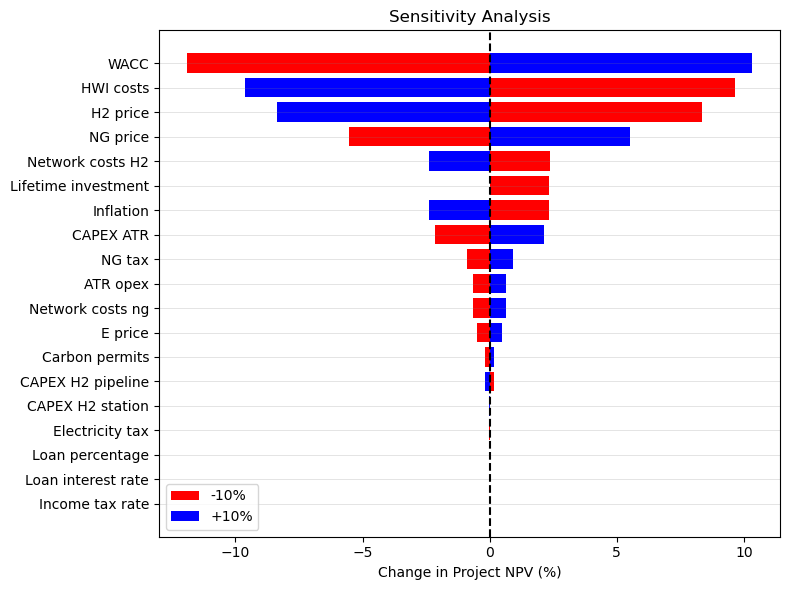

In [ ]:
tornado_plot(df_sa_project_npv, project_npv_base_case, 'Project NPV')

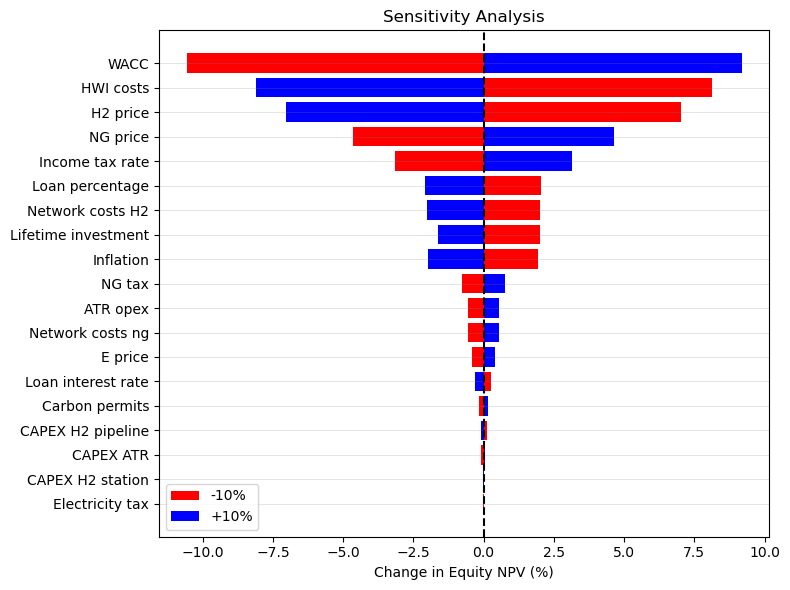

In [ ]:
tornado_plot(df_sa_equity_npv,equity_npv_base_case, 'Equity NPV')

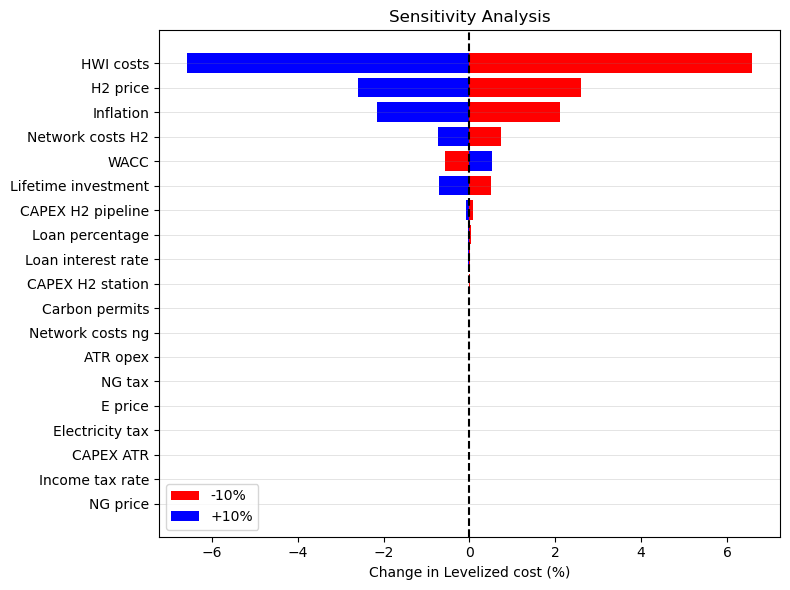

In [ ]:
tornado_plot(df_sa_levelized_cost,levelized_cost_base_case, 'Levelized cost')

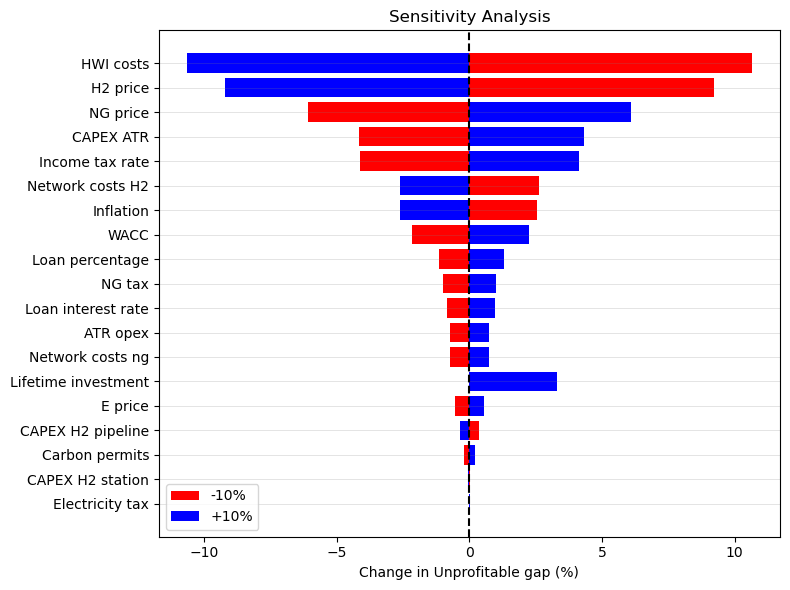

In [ ]:
tornado_plot(df_sa_unprofitable_gap,unprofitable_gap_base_case, 'Unprofitable gap')

Cumulative equity and debt figure

In [ ]:
df_cumulative_equity_and_debt_cashflows = cumulative_equity_and_debt_cashflows(bh_capex_h2_receiving_station,
                                                                               bh_capex_h2_pipeline,
                                                                               df_bh_atr_capex,
                                                                               bh_network_costs_h2,
                                                                               bh_h2_price,
                                                                               bh_hwi_costs,
                                                                               df_bh_atr_opex,
                                                                               bh_network_costs_ng,
                                                                               bh_carbon_permits,
                                                                               bh_ng_price,
                                                                               bh_ng_tax_cost,
                                                                               bh_e_price,
                                                                               bh_electricity_tax,
                                                                               bh_inflation,
                                                                               bh_loan_percentage,
                                                                               bh_loan_interest_rate,
                                                                               bh_income_tax_rate,
                                                                               bh_lifetime)

In [ ]:
df_cumulative_equity_and_debt_cashflows

cumulative equity and debt,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,...,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056
cumulative_equity_cashflow,-4.29,52.102556,108.385717,-172.082996,-457.853678,-749.024640,-1045.695395,-1275.095298,-1508.740059,-1746.703427,...,-4228.658876,-4465.810505,-4700.475468,-4925.182173,-5154.289719,-5387.886123,-5626.061163,-5868.906411,-6116.515271,-6094.992668
cumulative_debt_cashflow,-0.00,-16.087500,-32.175000,-30.894608,-29.524588,-28.058668,-26.490132,-24.811799,-23.015983,-21.094460,...,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000


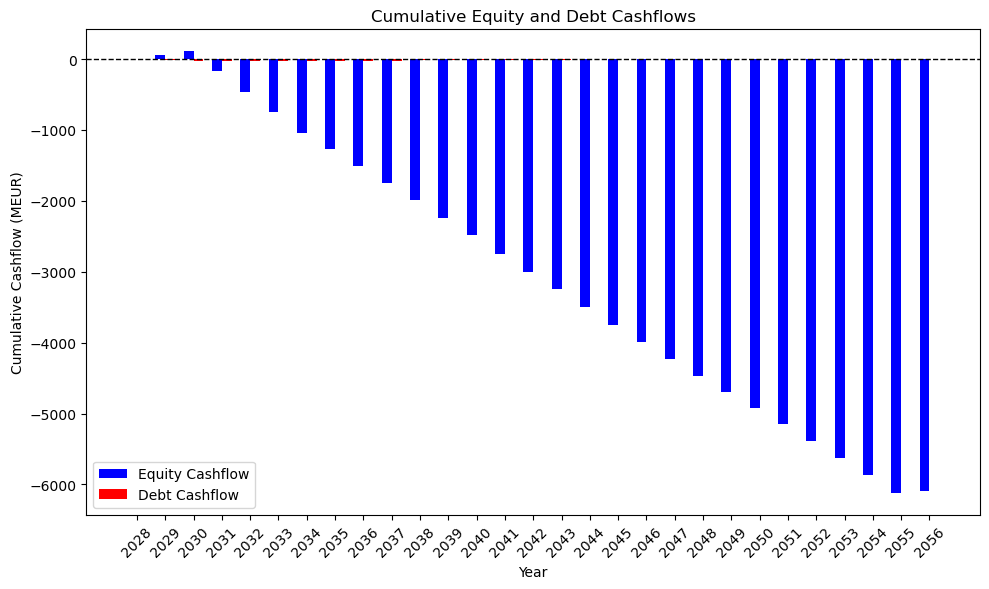

In [ ]:
# Years from 2027 to 2057
years = construct_calendar_year_list(bh_lifetime)  

cumulative_equity_cashflow = df_cumulative_equity_and_debt_cashflows.loc['cumulative_equity_cashflow'].tolist()

cumulative_debt_cashflow = df_cumulative_equity_and_debt_cashflows.loc['cumulative_debt_cashflow'].tolist()

# Set the width of each bar
bar_width = 0.35

# Set the position of the bars on the x-axis
r1 = np.arange(len(years))
r2 = [x + bar_width for x in r1]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars for cumulative equity cashflow
ax.bar(r1, cumulative_equity_cashflow, color='blue', width=bar_width, label='Equity Cashflow')

# Create bars for cumulative debt cashflow
ax.bar(r2, cumulative_debt_cashflow, color='red', width=bar_width, label='Debt Cashflow')

# Add a horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Add labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Cashflow (MEUR)')
ax.set_title('Cumulative Equity and Debt Cashflows')

# Add xticks on the middle of the group bars
ax.set_xticks([r + bar_width/2 for r in range(len(years))])
ax.set_xticklabels(years, rotation=45)

# Add legend
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()
